# Pulsed ODMR result plots

Results from `pulsed_odmr.py` (pulsed ODMR frequency sweep, `rabi.py`'s
gated laser/MW pulse sequence with a fixed `tau_mw_us`, only `freq_hz`
swept). Split out from `rabi_result.ipynb` (which covers `rabi.py`'s own
`tau_mw` Rabi sweeps) since the two are separate measurement types.

## Load data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

DATA_DIR = "D:/pulsed_odmr"

## pulsed1 (pulsed_odmr.py frequency sweep) + Lorentzian fit

`tau_mw=5.0` us, `n_reps=250`, `coil_current_a=2.5`, fixed shot period per
point (frequency sweep, not `tau_mw`). 5/144 points (`3.5%`) show
`reference_unlock=True` -- EXCLUDED from the fit (see the `pulsed3` entry
below for why: an unlock-flagged point can be a severe corrupted-reading
outlier, not just a noisy one). Fits R vs. frequency to a single
Lorentzian dip/peak to extract the ODMR linewidth (FWHM).

pulsed1: 144 points, 2.896675-2.910975 GHz
5/144 points flagged reference_unlock (excluded from fit)
tau_mw_us=5.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
drive_power_dbm=0.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0
anchor_free_reps=1000
extra_settle_s=1.0
coil_current_a=2.5


pulsed1 Lorentzian fit: f0 = 2.900940 GHz, FWHM (linewidth) = 23.6900 +/- 10.9576 MHz
[UNRELIABLE] relative uncertainty 46%, fitted FWHM is 166% of the scanned span (14.3 MHz) -- the window likely doesn't fully contain both wings of the resonance; widen start_hz/stop_hz before trusting this number


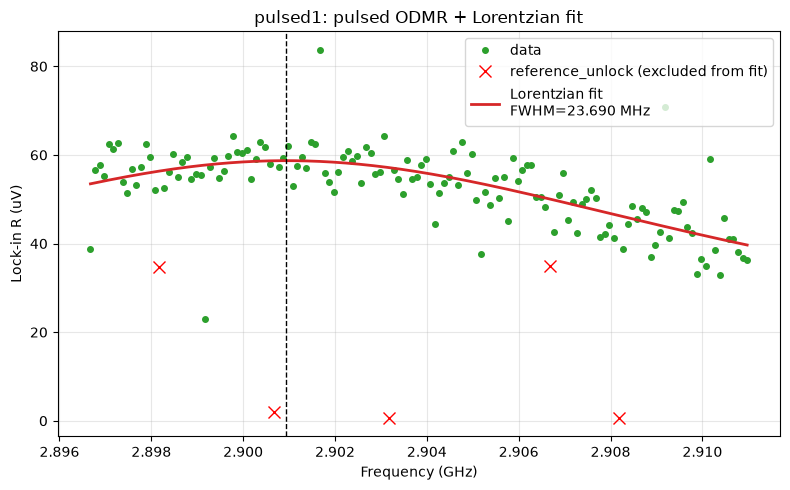

In [2]:
name_p1 = "pulsed1"
run_path_p1 = f"{DATA_DIR}/{name_p1}"
freqs_p1 = np.load(f"{run_path_p1}/{name_p1}_pulsed_odmr_freqs_hz.npy")
x_p1 = np.load(f"{run_path_p1}/{name_p1}_pulsed_odmr_x.npy")
y_p1 = np.load(f"{run_path_p1}/{name_p1}_pulsed_odmr_y.npy")
r_p1 = np.sqrt(x_p1**2 + y_p1**2)
unlock_p1 = np.load(f"{run_path_p1}/{name_p1}_pulsed_odmr_reference_unlock.npy")

with open(f"{run_path_p1}/{name_p1}_pulsed_odmr_metadata.txt") as fh:
    metadata_text_p1 = fh.read()
print(f"{name_p1}: {len(freqs_p1)} points, {freqs_p1.min()/1e9:.6f}-{freqs_p1.max()/1e9:.6f} GHz")
print(f"{unlock_p1.sum()}/{len(unlock_p1)} points flagged reference_unlock (excluded from fit)")
print(metadata_text_p1)


def lorentzian(f, f0, fwhm, amp, offset):
    """amp can be negative (dip) or positive (peak); fwhm only appears
    squared below, so curve_fit can converge to either sign -- always
    take abs(fwhm) when reporting/plotting the fitted linewidth."""
    hwhm = fwhm / 2
    return offset + amp * hwhm**2 / ((f - f0)**2 + hwhm**2)


def report_lorentzian_fit(name, freqs_ghz, r, unlock, span_ghz):
    """Fits r vs freqs_ghz (excluding unlock-flagged points) to a single
    Lorentzian, reports f0/FWHM with abs(fwhm) (sign is a fit degeneracy,
    not physical), and flags the fit as unreliable if FWHM's relative
    uncertainty is large or the fitted FWHM approaches the scanned span
    (both signs that the window doesn't fully contain the lineshape)."""
    good = ~unlock
    median_r = np.median(r[good])
    idx_extreme = np.argmax(np.abs(r[good] - median_r))
    p0 = [freqs_ghz[good][idx_extreme], span_ghz / 4,
          r[good][idx_extreme] - median_r, median_r]

    popt, pcov = curve_fit(lorentzian, freqs_ghz[good], r[good], p0=p0, maxfev=5000)
    f0_fit, fwhm_fit, amp_fit, offset_fit = popt
    fwhm_fit = abs(fwhm_fit)
    perr = np.sqrt(np.diag(pcov))
    fwhm_err = perr[1]

    rel_err = fwhm_err / fwhm_fit if fwhm_fit > 0 else np.inf
    span_fraction = fwhm_fit / span_ghz
    print(f"\n{name} Lorentzian fit: f0 = {f0_fit:.6f} GHz, "
          f"FWHM (linewidth) = {fwhm_fit*1e3:.4f} +/- {fwhm_err*1e3:.4f} MHz")
    if rel_err > 0.5 or span_fraction > 0.5:
        print(f"[UNRELIABLE] relative uncertainty {rel_err*100:.0f}%, "
              f"fitted FWHM is {span_fraction*100:.0f}% of the scanned span "
              f"({span_ghz*1e3:.1f} MHz) -- the window likely doesn't fully "
              f"contain both wings of the resonance; widen start_hz/stop_hz "
              f"before trusting this number")
    return f0_fit, fwhm_fit, fwhm_err, popt


span_ghz_p1 = (freqs_p1.max() - freqs_p1.min()) / 1e9
freqs_ghz_p1 = freqs_p1 / 1e9
f0_fit, fwhm_fit_ghz, fwhm_err_ghz, popt = report_lorentzian_fit(
    name_p1, freqs_ghz_p1, r_p1, unlock_p1, span_ghz_p1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_p1[~unlock_p1], r_p1[~unlock_p1] * 1e6, "o", ms=4, color="tab:green", label="data")
ax.plot(freqs_ghz_p1[unlock_p1], r_p1[unlock_p1] * 1e6, "x", ms=8, color="red",
        label="reference_unlock (excluded from fit)")
freqs_fit = np.linspace(freqs_ghz_p1.min(), freqs_ghz_p1.max(), 1000)
ax.plot(freqs_fit, lorentzian(freqs_fit, *popt) * 1e6, "-", lw=2, color="tab:red",
        label=f"Lorentzian fit\nFWHM={fwhm_fit_ghz*1e3:.3f} MHz")
ax.axvline(f0_fit, color="k", ls="--", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_p1}: pulsed ODMR + Lorentzian fit")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## pulsed2 (pulsed_odmr.py frequency sweep) + Lorentzian fit

`tau_mw=5.0` us, `n_reps=250`, `coil_current_a=4.0` (different from
`pulsed1`'s `2.5` A -- a different coil-scan optimum/resonance point).
5/122 points (`4.1%`) show `reference_unlock=True` -- excluded from the
fit, same as `pulsed1`. Reuses the `lorentzian()` fit function defined
above.

pulsed2: 122 points, 2.794700-2.806800 GHz
5/122 points flagged reference_unlock (excluded from fit)
tau_mw_us=5.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
drive_power_dbm=0.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0
anchor_free_reps=1000
extra_settle_s=1.0
coil_current_a=4.0


pulsed2 Lorentzian fit: f0 = 2.805155 GHz, FWHM (linewidth) = 11.3874 +/- 4.5949 MHz
[UNRELIABLE] relative uncertainty 40%, fitted FWHM is 94% of the scanned span (12.1 MHz) -- the window likely doesn't fully contain both wings of the resonance; widen start_hz/stop_hz before trusting this number


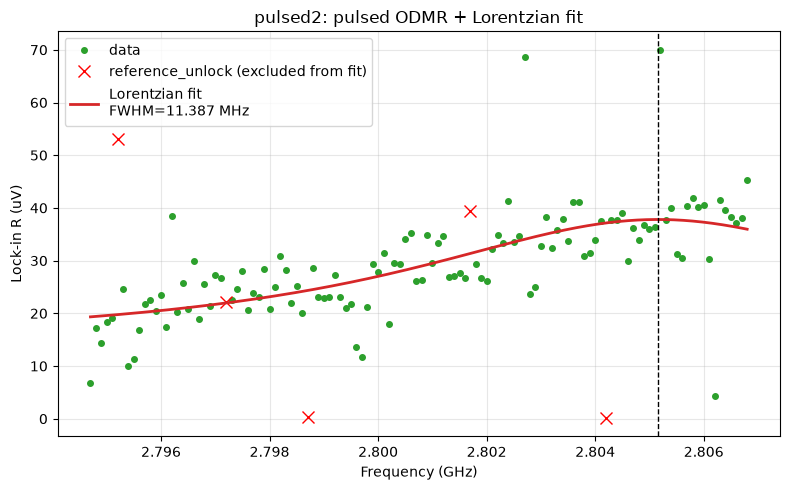

In [3]:
name_p2 = "pulsed2"
run_path_p2 = f"{DATA_DIR}/{name_p2}"
freqs_p2 = np.load(f"{run_path_p2}/{name_p2}_pulsed_odmr_freqs_hz.npy")
x_p2 = np.load(f"{run_path_p2}/{name_p2}_pulsed_odmr_x.npy")
y_p2 = np.load(f"{run_path_p2}/{name_p2}_pulsed_odmr_y.npy")
r_p2 = np.sqrt(x_p2**2 + y_p2**2)
unlock_p2 = np.load(f"{run_path_p2}/{name_p2}_pulsed_odmr_reference_unlock.npy")

with open(f"{run_path_p2}/{name_p2}_pulsed_odmr_metadata.txt") as fh:
    metadata_text_p2 = fh.read()
print(f"{name_p2}: {len(freqs_p2)} points, {freqs_p2.min()/1e9:.6f}-{freqs_p2.max()/1e9:.6f} GHz")
print(f"{unlock_p2.sum()}/{len(unlock_p2)} points flagged reference_unlock (excluded from fit)")
print(metadata_text_p2)

span_ghz_p2 = (freqs_p2.max() - freqs_p2.min()) / 1e9
freqs_ghz_p2 = freqs_p2 / 1e9
f0_fit2, fwhm_fit_ghz2, fwhm_err_ghz2, popt2 = report_lorentzian_fit(
    name_p2, freqs_ghz_p2, r_p2, unlock_p2, span_ghz_p2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_p2[~unlock_p2], r_p2[~unlock_p2] * 1e6, "o", ms=4, color="tab:green", label="data")
ax.plot(freqs_ghz_p2[unlock_p2], r_p2[unlock_p2] * 1e6, "x", ms=8, color="red",
        label="reference_unlock (excluded from fit)")
freqs_fit2 = np.linspace(freqs_ghz_p2.min(), freqs_ghz_p2.max(), 1000)
ax.plot(freqs_fit2, lorentzian(freqs_fit2, *popt2) * 1e6, "-", lw=2, color="tab:red",
        label=f"Lorentzian fit\nFWHM={fwhm_fit_ghz2*1e3:.3f} MHz")
ax.axvline(f0_fit2, color="k", ls="--", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_p2}: pulsed ODMR + Lorentzian fit")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## pulsed3 (pulsed_odmr.py frequency sweep) + Lorentzian fit

`tau_mw=5.0` us, `n_reps=250`, `coil_current_a=3.0`. 4/112 points (`3.6%`)
show `reference_unlock=True`.

**Found while fitting this one**: the fit's initial-guess logic (pick the
point farthest from the median as the resonance extremum) originally
picked one of the `reference_unlock`-flagged points -- a single corrupted
reading near zero (`R~0.27 uV`) sandwiched between neighbors reading
`~65-70 uV` on both sides -- as the "dip," which then made `curve_fit`
fail to converge entirely (`Optimal parameters not found`). Fixed by
excluding `reference_unlock`-flagged points from the fit across all three
`pulsed*` cells above (not just flagging them cosmetically as before) --
they're shown on the plot as red X's but never used for the initial guess
or the fit itself.

pulsed3: 112 points, 2.833900-2.845000 GHz
4/112 points flagged reference_unlock (excluded from fit)
tau_mw_us=5.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
drive_power_dbm=0.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0
anchor_free_reps=1000
extra_settle_s=1.0
coil_current_a=3.0


pulsed3 Lorentzian fit: f0 = 2.838557 GHz, FWHM (linewidth) = 694.4767 +/- 1178918.8937 MHz
[UNRELIABLE] relative uncertainty 169756%, fitted FWHM is 6257% of the scanned span (11.1 MHz) -- the window likely doesn't fully contain both wings of the resonance; widen start_hz/stop_hz before trusting this number


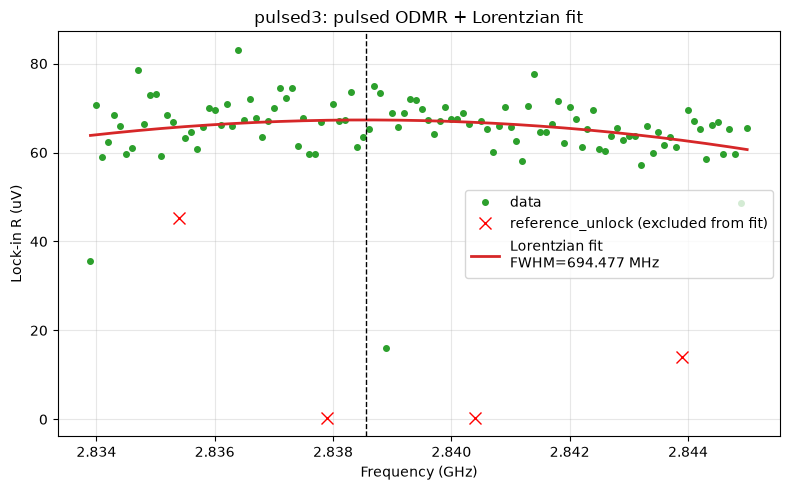

In [4]:
name_p3 = "pulsed3"
run_path_p3 = f"{DATA_DIR}/{name_p3}"
freqs_p3 = np.load(f"{run_path_p3}/{name_p3}_pulsed_odmr_freqs_hz.npy")
x_p3 = np.load(f"{run_path_p3}/{name_p3}_pulsed_odmr_x.npy")
y_p3 = np.load(f"{run_path_p3}/{name_p3}_pulsed_odmr_y.npy")
r_p3 = np.sqrt(x_p3**2 + y_p3**2)
unlock_p3 = np.load(f"{run_path_p3}/{name_p3}_pulsed_odmr_reference_unlock.npy")

with open(f"{run_path_p3}/{name_p3}_pulsed_odmr_metadata.txt") as fh:
    metadata_text_p3 = fh.read()
print(f"{name_p3}: {len(freqs_p3)} points, {freqs_p3.min()/1e9:.6f}-{freqs_p3.max()/1e9:.6f} GHz")
print(f"{unlock_p3.sum()}/{len(unlock_p3)} points flagged reference_unlock (excluded from fit)")
print(metadata_text_p3)

span_ghz_p3 = (freqs_p3.max() - freqs_p3.min()) / 1e9
freqs_ghz_p3 = freqs_p3 / 1e9
f0_fit3, fwhm_fit_ghz3, fwhm_err_ghz3, popt3 = report_lorentzian_fit(
    name_p3, freqs_ghz_p3, r_p3, unlock_p3, span_ghz_p3)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_p3[~unlock_p3], r_p3[~unlock_p3] * 1e6, "o", ms=4, color="tab:green", label="data")
ax.plot(freqs_ghz_p3[unlock_p3], r_p3[unlock_p3] * 1e6, "x", ms=8, color="red",
        label="reference_unlock (excluded from fit)")
freqs_fit3 = np.linspace(freqs_ghz_p3.min(), freqs_ghz_p3.max(), 1000)
ax.plot(freqs_fit3, lorentzian(freqs_fit3, *popt3) * 1e6, "-", lw=2, color="tab:red",
        label=f"Lorentzian fit\nFWHM={fwhm_fit_ghz3*1e3:.3f} MHz")
ax.axvline(f0_fit3, color="k", ls="--", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_p3}: pulsed ODMR + Lorentzian fit")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## pulsed4 (pulsed_odmr.py frequency sweep) + Lorentzian fit

`tau_mw=2.0` us, `n_reps=250`, `coil_current_a=2.5`, `anchor_free_reps=
80000` (up from `1000` in pulsed1-3) with `extra_settle_s=1.0`. **0/201
points show `reference_unlock=True`** -- fully clean, confirming the
`trigger_period_s`/`trigger_retrigger_free_reps` decoupling fix (added
this session after `measurement21-25`/`pulsed_odmr.py` investigation)
actually works on real hardware: a large `anchor_free_reps` no longer
drags the SDG1062X retrigger rate down with it. Widest scan yet (201
points, 20 MHz span, same as `pulsed1`'s span but far denser).

pulsed4: 201 points, 2.830000-2.850000 GHz
0/201 points flagged reference_unlock (excluded from fit)
tau_mw_us=2.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
drive_power_dbm=0.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=5e-05
phase_deg=0.0
anchor_free_reps=80000
extra_settle_s=1.0
coil_current_a=2.5


pulsed4 Lorentzian fit: f0 = 2.830529 GHz, FWHM (linewidth) = 7.0874 +/- 1.3134 MHz


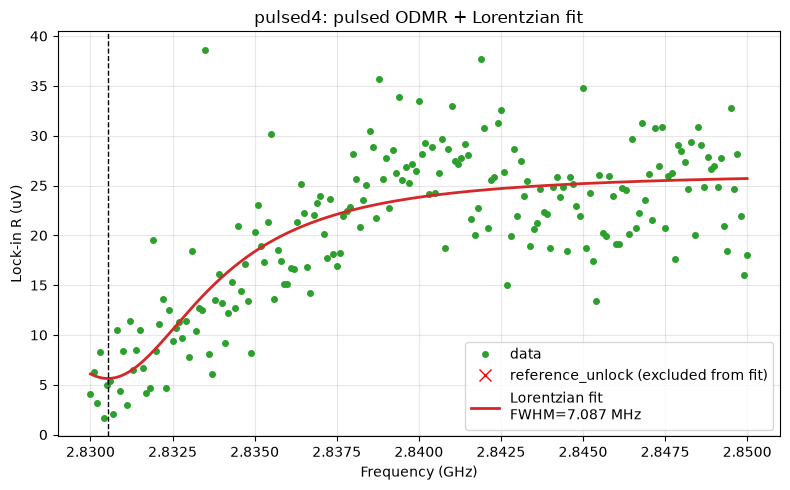

In [5]:
name_p4 = "pulsed4"
run_path_p4 = f"{DATA_DIR}/{name_p4}"
freqs_p4 = np.load(f"{run_path_p4}/{name_p4}_pulsed_odmr_freqs_hz.npy")
x_p4 = np.load(f"{run_path_p4}/{name_p4}_pulsed_odmr_x.npy")
y_p4 = np.load(f"{run_path_p4}/{name_p4}_pulsed_odmr_y.npy")
r_p4 = np.sqrt(x_p4**2 + y_p4**2)
unlock_p4 = np.load(f"{run_path_p4}/{name_p4}_pulsed_odmr_reference_unlock.npy")

with open(f"{run_path_p4}/{name_p4}_pulsed_odmr_metadata.txt") as fh:
    metadata_text_p4 = fh.read()
print(f"{name_p4}: {len(freqs_p4)} points, {freqs_p4.min()/1e9:.6f}-{freqs_p4.max()/1e9:.6f} GHz")
print(f"{unlock_p4.sum()}/{len(unlock_p4)} points flagged reference_unlock (excluded from fit)")
print(metadata_text_p4)

span_ghz_p4 = (freqs_p4.max() - freqs_p4.min()) / 1e9
freqs_ghz_p4 = freqs_p4 / 1e9
f0_fit4, fwhm_fit_ghz4, fwhm_err_ghz4, popt4 = report_lorentzian_fit(
    name_p4, freqs_ghz_p4, r_p4, unlock_p4, span_ghz_p4)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_p4[~unlock_p4], r_p4[~unlock_p4] * 1e6, "o", ms=4, color="tab:green", label="data")
ax.plot(freqs_ghz_p4[unlock_p4], r_p4[unlock_p4] * 1e6, "x", ms=8, color="red",
        label="reference_unlock (excluded from fit)")
freqs_fit4 = np.linspace(freqs_ghz_p4.min(), freqs_ghz_p4.max(), 1000)
ax.plot(freqs_fit4, lorentzian(freqs_fit4, *popt4) * 1e6, "-", lw=2, color="tab:red",
        label=f"Lorentzian fit\nFWHM={fwhm_fit_ghz4*1e3:.3f} MHz")
ax.axvline(f0_fit4, color="k", ls="--", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_p4}: pulsed ODMR + Lorentzian fit")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Averaged: pulsed4 + pulsed5, double-Lorentzian fit

Same frequency grid confirmed matching exactly (201 points, 2.83-2.85
GHz), same params (`tau_mw=2.0` us, `coil_current_a=2.5` A,
`anchor_free_reps=80000`), both fully clean (0 `reference_unlock` points
in either). Averaged elementwise (X/Y averaged first, then R from the
averaged X/Y, excluding any unlock-flagged points -- none here, but kept
for consistency with the other `pulsed*` cells). Fits a sum of two
independent Lorentzian peaks (same `double_lorentzian()` used on
`measurement_scan_dense` in `cw_odmr_result.ipynb`), with an AIC
comparison against a single-Lorentzian fit to check whether the second
peak actually earns its added complexity on this data.

pulsed4: 201 points, 2.830000-2.850000 GHz, 0/201 unlock
tau_mw_us=2.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
drive_power_dbm=0.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=5e-05
phase_deg=0.0
anchor_free_reps=80000
extra_settle_s=1.0
coil_current_a=2.5

pulsed5: 201 points, 2.830000-2.850000 GHz, 0/201 unlock
tau_mw_us=2.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
drive_power_dbm=0.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=5e-05
phase_deg=0.0
anchor_free_reps=80000
extra_settle_s=1.0
coil_current_a=2.5


Peak 1: f0 = 2.839634 GHz, FWHM = 11.8532 +/- 1.6576 MHz, amp = 26.162 uV
Peak 2: f0 = 2.848482 GHz, FWHM = 9.0726 +/- 2.2277 MHz, amp = 18.963 uV
Peak separation: 8.848 MHz
[NOTE] peak separation is smaller than the average of the two fitted widths -- the two peaks strongly overlap

Single Lorentzian: RSS = 2508.888 (uV^2), AIC = -5038.45
Double Lorentzian: RSS = 1690.477 (uV^2), AIC = -5111.81
Do

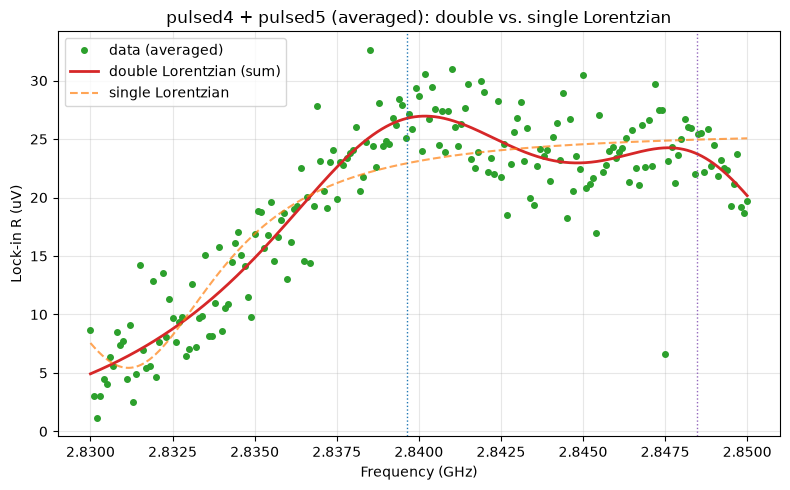

In [6]:
pool_names_p45 = ["pulsed4", "pulsed5"]

pool_data_p45 = []
for name in pool_names_p45:
    run_path = f"{DATA_DIR}/{name}"
    freqs = np.load(f"{run_path}/{name}_pulsed_odmr_freqs_hz.npy")
    x = np.load(f"{run_path}/{name}_pulsed_odmr_x.npy")
    y = np.load(f"{run_path}/{name}_pulsed_odmr_y.npy")
    unlock = np.load(f"{run_path}/{name}_pulsed_odmr_reference_unlock.npy")
    with open(f"{run_path}/{name}_pulsed_odmr_metadata.txt") as fh:
        print(f"{name}: {len(freqs)} points, {freqs.min()/1e9:.6f}-{freqs.max()/1e9:.6f} GHz, "
              f"{unlock.sum()}/{len(unlock)} unlock")
        print(fh.read())
    pool_data_p45.append(dict(freqs=freqs, x=x, y=y, unlock=unlock))

freqs_p45 = pool_data_p45[0]["freqs"]
assert all(np.allclose(d["freqs"], freqs_p45) for d in pool_data_p45), \
    "frequency grids must match exactly to average elementwise"

# Points flagged reference_unlock in EITHER run are excluded from both
# before averaging (none here, but kept consistent with the other
# pulsed* cells' convention of never trusting an unlock-flagged point).
unlock_p45 = np.any([d["unlock"] for d in pool_data_p45], axis=0)
good_p45 = ~unlock_p45

x_avg_p45 = np.mean([d["x"] for d in pool_data_p45], axis=0)
y_avg_p45 = np.mean([d["y"] for d in pool_data_p45], axis=0)
r_avg_p45 = np.sqrt(x_avg_p45**2 + y_avg_p45**2)

freqs_ghz_p45 = freqs_p45 / 1e9
span_ghz_p45 = freqs_ghz_p45.max() - freqs_ghz_p45.min()


def double_lorentzian(f, f1, fwhm1, amp1, f2, fwhm2, amp2, offset):
    """Sum of two independent Lorentzian peaks + one shared baseline
    offset. Each fwhm only appears squared -- take abs() when reporting."""
    term1 = amp1 * (fwhm1 / 2) ** 2 / ((f - f1) ** 2 + (fwhm1 / 2) ** 2)
    term2 = amp2 * (fwhm2 / 2) ** 2 / ((f - f2) ** 2 + (fwhm2 / 2) ** 2)
    return offset + term1 + term2


# Initial guess: split the (good) range in half, use each half's own max
# as a candidate peak center -- same robust strategy as the cw_odmr_
# result.ipynb double-Lorentzian fit.
freqs_good_p45 = freqs_ghz_p45[good_p45]
r_good_p45 = r_avg_p45[good_p45]
mid_p45 = len(freqs_good_p45) // 2
left_f, right_f = freqs_good_p45[:mid_p45], freqs_good_p45[mid_p45:]
left_r, right_r = r_good_p45[:mid_p45], r_good_p45[mid_p45:]
median_r_p45 = np.median(r_good_p45)

idx_left = np.argmax(left_r)
idx_right = np.argmax(right_r)
p0_dbl_p45 = [
    left_f[idx_left], span_ghz_p45 / 8, left_r[idx_left] - median_r_p45,
    right_f[idx_right], span_ghz_p45 / 8, right_r[idx_right] - median_r_p45,
    median_r_p45,
]

popt_dbl_p45, pcov_dbl_p45 = curve_fit(
    double_lorentzian, freqs_good_p45, r_good_p45, p0=p0_dbl_p45, maxfev=10000)
f1_p45, fwhm1_p45, amp1_p45, f2_p45, fwhm2_p45, amp2_p45, offset_p45 = popt_dbl_p45
fwhm1_p45, fwhm2_p45 = abs(fwhm1_p45), abs(fwhm2_p45)
perr_dbl_p45 = np.sqrt(np.diag(pcov_dbl_p45))

print(f"\nPeak 1: f0 = {f1_p45:.6f} GHz, FWHM = {fwhm1_p45*1e3:.4f} +/- "
      f"{perr_dbl_p45[1]*1e3:.4f} MHz, amp = {amp1_p45*1e6:.3f} uV")
print(f"Peak 2: f0 = {f2_p45:.6f} GHz, FWHM = {fwhm2_p45*1e3:.4f} +/- "
      f"{perr_dbl_p45[4]*1e3:.4f} MHz, amp = {amp2_p45*1e6:.3f} uV")
separation_mhz_p45 = abs(f2_p45 - f1_p45) * 1e3
print(f"Peak separation: {separation_mhz_p45:.3f} MHz")
if separation_mhz_p45 < (fwhm1_p45 + fwhm2_p45) * 1e3 / 2:
    print("[NOTE] peak separation is smaller than the average of the two "
          "fitted widths -- the two peaks strongly overlap")

# AIC comparison against a single Lorentzian on the same (good) data.
p0_single_p45 = [freqs_good_p45[np.argmax(np.abs(r_good_p45 - median_r_p45))],
                 span_ghz_p45 / 4,
                 r_good_p45[np.argmax(np.abs(r_good_p45 - median_r_p45))] - median_r_p45,
                 median_r_p45]
popt_single_p45, _ = curve_fit(lorentzian, freqs_good_p45, r_good_p45,
                                p0=p0_single_p45, maxfev=5000)

n_points_p45 = len(r_good_p45)
rss_single_p45 = np.sum((r_good_p45 - lorentzian(freqs_good_p45, *popt_single_p45)) ** 2)
rss_double_p45 = np.sum((r_good_p45 - double_lorentzian(freqs_good_p45, *popt_dbl_p45)) ** 2)
aic_single_p45 = n_points_p45 * np.log(rss_single_p45 / n_points_p45) + 2 * 4
aic_double_p45 = n_points_p45 * np.log(rss_double_p45 / n_points_p45) + 2 * 7
print(f"\nSingle Lorentzian: RSS = {rss_single_p45*1e12:.3f} (uV^2), AIC = {aic_single_p45:.2f}")
print(f"Double Lorentzian: RSS = {rss_double_p45*1e12:.3f} (uV^2), AIC = {aic_double_p45:.2f}")
if aic_double_p45 < aic_single_p45:
    print(f"Double Lorentzian preferred (AIC lower by {aic_single_p45 - aic_double_p45:.2f})")
else:
    print(f"Single Lorentzian preferred (AIC lower by {aic_double_p45 - aic_single_p45:.2f}) "
          f"-- the second peak is NOT justified by this data")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_good_p45, r_good_p45 * 1e6, "o", ms=4, color="tab:green", label="data (averaged)")
freqs_fit_p45 = np.linspace(freqs_ghz_p45.min(), freqs_ghz_p45.max(), 2000)
ax.plot(freqs_fit_p45, double_lorentzian(freqs_fit_p45, *popt_dbl_p45) * 1e6,
        "-", lw=2, color="tab:red", label="double Lorentzian (sum)")
ax.plot(freqs_fit_p45, lorentzian(freqs_fit_p45, *popt_single_p45) * 1e6,
        "--", lw=1.5, color="tab:orange", alpha=0.7, label="single Lorentzian")
ax.axvline(f1_p45, color="tab:blue", ls=":", lw=1)
ax.axvline(f2_p45, color="tab:purple", ls=":", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title("pulsed4 + pulsed5 (averaged): double vs. single Lorentzian")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## pulsed_repeat (in progress -- only completed repeats so far)

First real-hardware use of `pulsed_odmr.py`'s new `run-repeat` command.
Still running -- 4 repeats completed so far. Auto-discovers completed
repeats and averages X/Y across them (R from the averaged X/Y), same
pattern as `rabi_result.ipynb`'s in-progress `measurement21`/`measurement
22` cells -- re-run this cell later to pick up more repeats as they
finish.

found 6 completed repeats: [0, 1, 2, 3, 4, 5]
averaging 6/6 repeats
tau_mw_us=2.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
drive_power_dbm=0.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=5e-05
phase_deg=0.0
anchor_free_reps=80000
extra_settle_s=1.0
coil_current_a=2.5



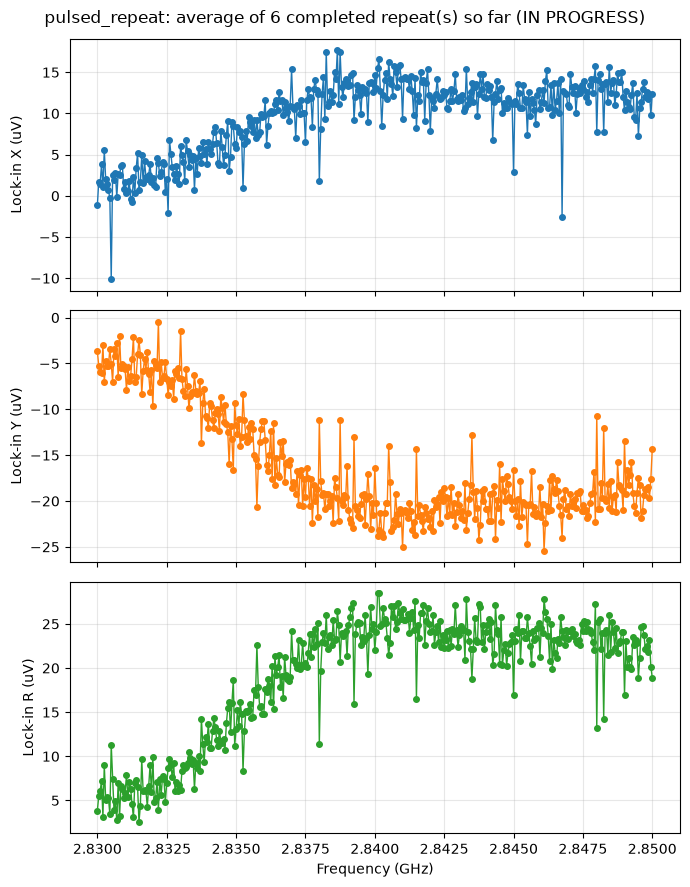

In [7]:
import glob
import re

name_pr = "pulsed_repeat"
run_path_pr = f"{DATA_DIR}/{name_pr}"

repeat_indices_pr = sorted(
    int(re.search(r"_repeat(\d+)_pulsed_odmr_x\.npy$", p).group(1))
    for p in glob.glob(f"{run_path_pr}/{name_pr}_repeat*_pulsed_odmr_x.npy")
)
print(f"found {len(repeat_indices_pr)} completed repeats: {repeat_indices_pr}")

freqs_ref_pr = None
xs_pr, ys_pr = [], []
for i in repeat_indices_pr:
    prefix = f"{run_path_pr}/{name_pr}_repeat{i}"
    freqs_i = np.load(f"{prefix}_pulsed_odmr_freqs_hz.npy")
    if freqs_ref_pr is None:
        freqs_ref_pr = freqs_i
    elif len(freqs_i) != len(freqs_ref_pr) or not np.allclose(freqs_i, freqs_ref_pr):
        print(f"  repeat{i}: freqs_hz grid mismatch ({len(freqs_i)} vs "
              f"{len(freqs_ref_pr)} points) -- excluded")
        continue
    xs_pr.append(np.load(f"{prefix}_pulsed_odmr_x.npy"))
    ys_pr.append(np.load(f"{prefix}_pulsed_odmr_y.npy"))

print(f"averaging {len(xs_pr)}/{len(repeat_indices_pr)} repeats")

with open(f"{run_path_pr}/{name_pr}_repeat0_pulsed_odmr_metadata.txt") as fh:
    print(fh.read())

x_avg_pr = np.mean(xs_pr, axis=0)
y_avg_pr = np.mean(ys_pr, axis=0)
r_avg_pr = np.sqrt(x_avg_pr**2 + y_avg_pr**2)

freqs_ghz_pr = freqs_ref_pr / 1e9

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(freqs_ghz_pr, x_avg_pr * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[1].plot(freqs_ghz_pr, y_avg_pr * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[2].plot(freqs_ghz_pr, r_avg_pr * 1e6, "o-", ms=4, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("Frequency (GHz)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"{name_pr}: average of {len(xs_pr)} completed repeat(s) so far (IN PROGRESS)")
plt.tight_layout()
plt.show()

## pulsed_repeat: double-Lorentzian fit (in progress)

Same double vs. single Lorentzian comparison as `pulsed4`+`pulsed5`
above, applied to `pulsed_repeat`'s current average (whatever repeats
have completed so far) -- reuses the `lorentzian()`/`double_lorentzian()`
functions already defined above. Re-run after re-running the average
cell above to reflect any newly-completed repeats.

Peak 1: f0 = 2.844037 GHz, FWHM = 14.3049 +/- 284.6310 MHz, amp = -3072.325 uV
Peak 2: f0 = 2.844034 GHz, FWHM = 14.4302 +/- 285.8862 MHz, amp = 3108.437 uV
Peak separation: 0.003 MHz
[NOTE] peak separation is smaller than the average of the two fitted widths -- the two peaks strongly overlap

Single Lorentzian: RSS = 2455.509 (uV^2), AIC = -10345.38
Double Lorentzian: RSS = 1839.876 (uV^2), AIC = -10455.12
Double Lorentzian preferred (AIC lower by 109.74)


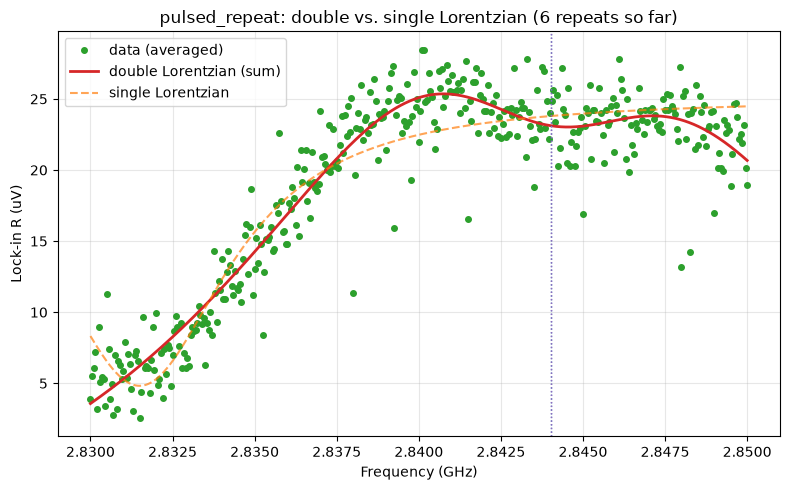

In [8]:
span_ghz_pr = freqs_ghz_pr.max() - freqs_ghz_pr.min()
median_r_pr = np.median(r_avg_pr)

mid_pr = len(freqs_ghz_pr) // 2
left_f_pr, right_f_pr = freqs_ghz_pr[:mid_pr], freqs_ghz_pr[mid_pr:]
left_r_pr, right_r_pr = r_avg_pr[:mid_pr], r_avg_pr[mid_pr:]

idx_left_pr = np.argmax(left_r_pr)
idx_right_pr = np.argmax(right_r_pr)
p0_dbl_pr = [
    left_f_pr[idx_left_pr], span_ghz_pr / 8, left_r_pr[idx_left_pr] - median_r_pr,
    right_f_pr[idx_right_pr], span_ghz_pr / 8, right_r_pr[idx_right_pr] - median_r_pr,
    median_r_pr,
]

popt_dbl_pr, pcov_dbl_pr = curve_fit(
    double_lorentzian, freqs_ghz_pr, r_avg_pr, p0=p0_dbl_pr, maxfev=10000)
f1_pr, fwhm1_pr, amp1_pr, f2_pr, fwhm2_pr, amp2_pr, offset_pr = popt_dbl_pr
fwhm1_pr, fwhm2_pr = abs(fwhm1_pr), abs(fwhm2_pr)
perr_dbl_pr = np.sqrt(np.diag(pcov_dbl_pr))

print(f"Peak 1: f0 = {f1_pr:.6f} GHz, FWHM = {fwhm1_pr*1e3:.4f} +/- "
      f"{perr_dbl_pr[1]*1e3:.4f} MHz, amp = {amp1_pr*1e6:.3f} uV")
print(f"Peak 2: f0 = {f2_pr:.6f} GHz, FWHM = {fwhm2_pr*1e3:.4f} +/- "
      f"{perr_dbl_pr[4]*1e3:.4f} MHz, amp = {amp2_pr*1e6:.3f} uV")
separation_mhz_pr = abs(f2_pr - f1_pr) * 1e3
print(f"Peak separation: {separation_mhz_pr:.3f} MHz")
if separation_mhz_pr < (fwhm1_pr + fwhm2_pr) * 1e3 / 2:
    print("[NOTE] peak separation is smaller than the average of the two "
          "fitted widths -- the two peaks strongly overlap")

p0_single_pr = [freqs_ghz_pr[np.argmax(np.abs(r_avg_pr - median_r_pr))],
                span_ghz_pr / 4,
                r_avg_pr[np.argmax(np.abs(r_avg_pr - median_r_pr))] - median_r_pr,
                median_r_pr]
popt_single_pr, _ = curve_fit(lorentzian, freqs_ghz_pr, r_avg_pr,
                               p0=p0_single_pr, maxfev=5000)

n_points_pr = len(r_avg_pr)
rss_single_pr = np.sum((r_avg_pr - lorentzian(freqs_ghz_pr, *popt_single_pr)) ** 2)
rss_double_pr = np.sum((r_avg_pr - double_lorentzian(freqs_ghz_pr, *popt_dbl_pr)) ** 2)
aic_single_pr = n_points_pr * np.log(rss_single_pr / n_points_pr) + 2 * 4
aic_double_pr = n_points_pr * np.log(rss_double_pr / n_points_pr) + 2 * 7
print(f"\nSingle Lorentzian: RSS = {rss_single_pr*1e12:.3f} (uV^2), AIC = {aic_single_pr:.2f}")
print(f"Double Lorentzian: RSS = {rss_double_pr*1e12:.3f} (uV^2), AIC = {aic_double_pr:.2f}")
if aic_double_pr < aic_single_pr:
    print(f"Double Lorentzian preferred (AIC lower by {aic_single_pr - aic_double_pr:.2f})")
else:
    print(f"Single Lorentzian preferred (AIC lower by {aic_double_pr - aic_single_pr:.2f}) "
          f"-- the second peak is NOT justified by this data")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_pr, r_avg_pr * 1e6, "o", ms=4, color="tab:green", label="data (averaged)")
freqs_fit_pr = np.linspace(freqs_ghz_pr.min(), freqs_ghz_pr.max(), 2000)
ax.plot(freqs_fit_pr, double_lorentzian(freqs_fit_pr, *popt_dbl_pr) * 1e6,
        "-", lw=2, color="tab:red", label="double Lorentzian (sum)")
ax.plot(freqs_fit_pr, lorentzian(freqs_fit_pr, *popt_single_pr) * 1e6,
        "--", lw=1.5, color="tab:orange", alpha=0.7, label="single Lorentzian")
ax.axvline(f1_pr, color="tab:blue", ls=":", lw=1)
ax.axvline(f2_pr, color="tab:purple", ls=":", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_pr}: double vs. single Lorentzian ({len(xs_pr)} repeats so far)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## tau_scan1 (pulsed_odmr.py run-repeat, tau_mw_us_list) -- gain vs. tau_mw

First use of `pulsed_odmr.py`'s new `tau_mw_us_list` option: an independent
`run-repeat` batch (`n_reps=250`, `coil_current_a=0.0`, `drive_power_dbm=0.0`,
`anchor_free_reps=80000`) for each `tau_mw` in `[0.5, 1, 2, 4]` us, same
frequency grid each time. IN PROGRESS -- 2 repeats completed per tau_mw so
far. Auto-discovers completed repeats per tau_mw value and averages X/Y
across them, same pattern as the `pulsed_repeat` cell above -- re-run this
cell later to pick up more repeats as they finish. Plots all four tau_mw
spectra overlaid to compare peak depth/shape as a function of MW pulse
duration.

tau_mw=0.5 us: 2 repeats averaged, 401 points, 2.860000-2.880000 GHz
tau_mw=1 us: 2 repeats averaged, 401 points, 2.860000-2.880000 GHz


tau_mw=2 us: 2 repeats averaged, 401 points, 2.860000-2.880000 GHz
tau_mw=4 us: 2 repeats averaged, 401 points, 2.860000-2.880000 GHz


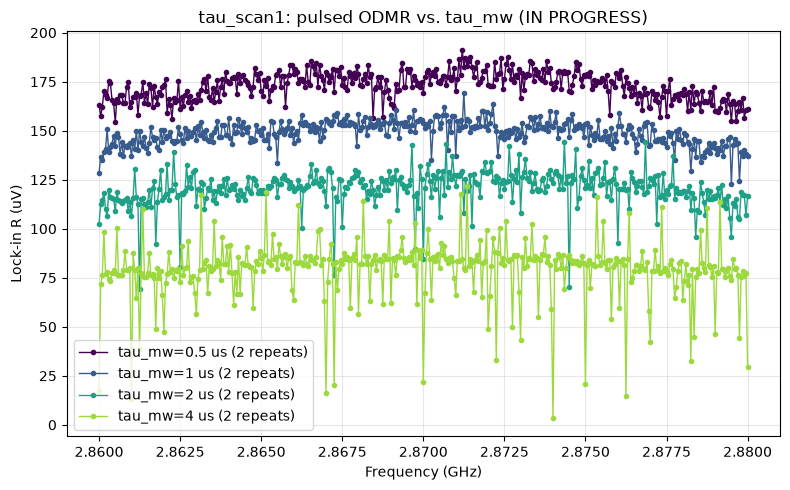

In [3]:
import glob
import re

DATA_DIR_TAU = "D:/pulsed_odmr"
name_ts = "tau_scan1"
run_path_ts = f"{DATA_DIR_TAU}/{name_ts}"
tau_values_us = [0.5, 1, 2, 4]


def _tau_tag(tau_mw_us):
    return f"{tau_mw_us:g}us".replace(".", "p")


tau_results = {}
for tau_mw_us in tau_values_us:
    tag = _tau_tag(tau_mw_us)
    prefix_glob = f"{run_path_ts}/{name_ts}_tau{tag}"

    repeat_indices = sorted(
        int(re.search(r"_repeat(\d+)_pulsed_odmr_x\.npy$", p).group(1))
        for p in glob.glob(f"{prefix_glob}_repeat*_pulsed_odmr_x.npy")
    )

    freqs_ref = None
    xs, ys = [], []
    for i in repeat_indices:
        prefix = f"{prefix_glob}_repeat{i}"
        freqs_i = np.load(f"{prefix}_pulsed_odmr_freqs_hz.npy")
        if freqs_ref is None:
            freqs_ref = freqs_i
        elif len(freqs_i) != len(freqs_ref) or not np.allclose(freqs_i, freqs_ref):
            print(f"  tau={tau_mw_us} us, repeat{i}: freqs_hz grid mismatch -- excluded")
            continue
        xs.append(np.load(f"{prefix}_pulsed_odmr_x.npy"))
        ys.append(np.load(f"{prefix}_pulsed_odmr_y.npy"))

    x_avg = np.mean(xs, axis=0)
    y_avg = np.mean(ys, axis=0)
    r_avg = np.sqrt(x_avg**2 + y_avg**2)
    tau_results[tau_mw_us] = dict(freqs_hz=freqs_ref, r=r_avg, n_repeats=len(xs))
    print(f"tau_mw={tau_mw_us} us: {len(xs)} repeats averaged, "
          f"{len(freqs_ref)} points, {freqs_ref.min()/1e9:.6f}-{freqs_ref.max()/1e9:.6f} GHz")

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(tau_values_us)))
for tau_mw_us, color in zip(tau_values_us, colors):
    d = tau_results[tau_mw_us]
    ax.plot(d["freqs_hz"] / 1e9, d["r"] * 1e6, "o-", ms=3, lw=1, color=color,
            label=f"tau_mw={tau_mw_us} us ({d['n_repeats']} repeats)")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_ts}: pulsed ODMR vs. tau_mw (IN PROGRESS)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### tau_scan1: tau_mw_us=2 alone

Same auto-discovery/averaging as the combined `tau_scan1` cell above, but
isolating just the `tau_mw=2` us batch on its own plot (X, Y, R panels,
same style as the `pulsed_repeat` cell) for a closer look.

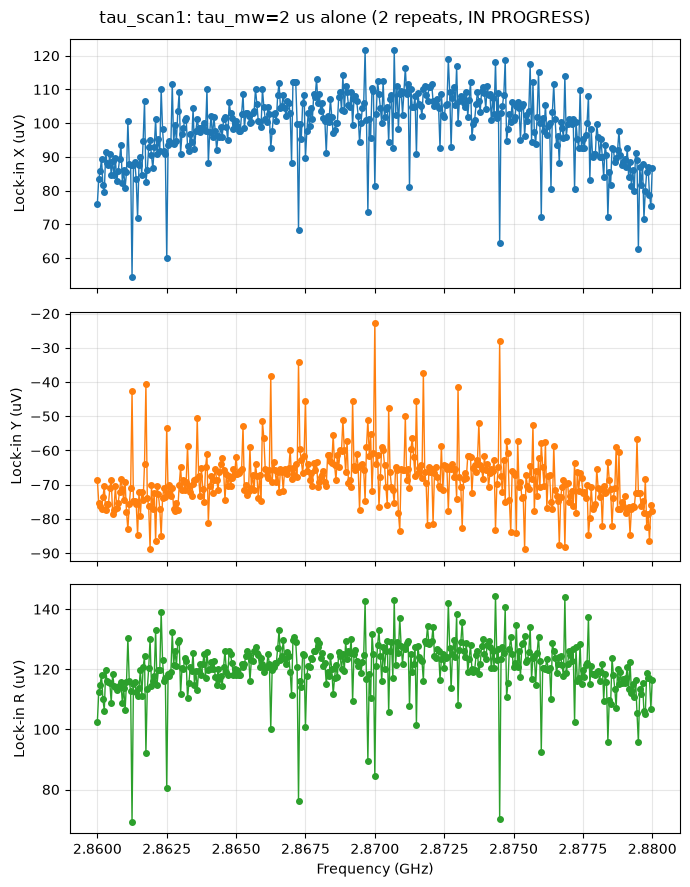

In [4]:
tau_mw_us_focus = 2

d_focus = tau_results[tau_mw_us_focus]
freqs_ghz_focus = d_focus["freqs_hz"] / 1e9

x_files_focus = sorted(glob.glob(
    f"{run_path_ts}/{name_ts}_tau{_tau_tag(tau_mw_us_focus)}_repeat*_pulsed_odmr_x.npy"))
y_files_focus = sorted(glob.glob(
    f"{run_path_ts}/{name_ts}_tau{_tau_tag(tau_mw_us_focus)}_repeat*_pulsed_odmr_y.npy"))
x_avg_focus = np.mean([np.load(p) for p in x_files_focus], axis=0)
y_avg_focus = np.mean([np.load(p) for p in y_files_focus], axis=0)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(freqs_ghz_focus, x_avg_focus * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[1].plot(freqs_ghz_focus, y_avg_focus * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[2].plot(freqs_ghz_focus, d_focus["r"] * 1e6, "o-", ms=4, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("Frequency (GHz)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"{name_ts}: tau_mw={tau_mw_us_focus} us alone "
             f"({d_focus['n_repeats']} repeats, IN PROGRESS)")
plt.tight_layout()
plt.show()

## tau_scan2 (pulsed_odmr.py run-repeat, tau_mw_us_list) -- gain vs. tau_mw

Second `tau_mw_us_list` batch, IN PROGRESS -- only `tau_mw=2` us has a
completed repeat so far (1 repeat). Same auto-discovery pattern as
`tau_scan1` above, but discovers which `tau_mw` values exist from the
`*_avg_*` files already on disk rather than a hardcoded list, since this
batch's full `tau_mw_us_list` isn't known from the data alone yet -- re-run
as more tau_mw values and repeats complete.

found tau_mw values: [2.0]
tau_mw=2.0 us: 1 repeats averaged, 51 points, 2.850000-2.860000 GHz


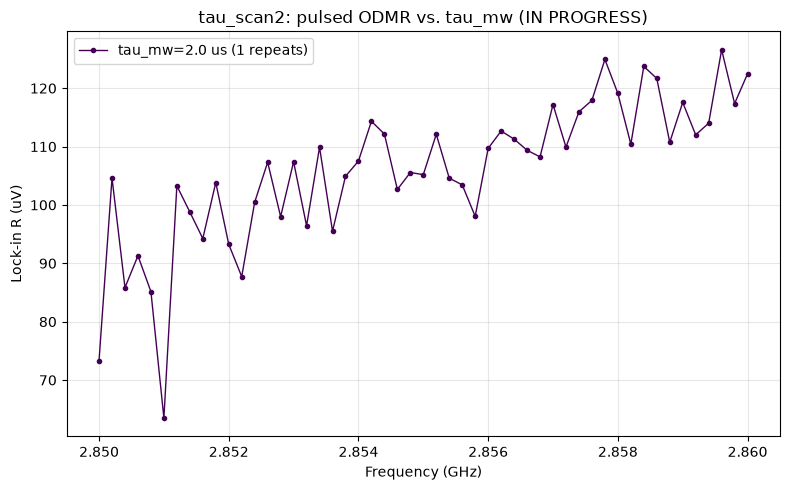

In [10]:
import glob
import re

name_ts2 = "tau_scan2"
run_path_ts2 = f"{DATA_DIR}/{name_ts2}"


def _tau_tag(tau_mw_us):
    return f"{tau_mw_us:g}us".replace(".", "p")


def _tau_from_tag(tag):
    return float(tag.replace("p", ".").replace("us", ""))


tau_tags_ts2 = sorted(
    {re.search(rf"_tau([0-9p]+us)_repeat\d+_pulsed_odmr_x\.npy$", p).group(1)
     for p in glob.glob(f"{run_path_ts2}/{name_ts2}_tau*_repeat*_pulsed_odmr_x.npy")},
    key=_tau_from_tag,
)
print(f"found tau_mw values: {[_tau_from_tag(t) for t in tau_tags_ts2]}")

tau_results_ts2 = {}
for tag in tau_tags_ts2:
    tau_mw_us = _tau_from_tag(tag)
    prefix_glob = f"{run_path_ts2}/{name_ts2}_tau{tag}"

    repeat_indices = sorted(
        int(re.search(r"_repeat(\d+)_pulsed_odmr_x\.npy$", p).group(1))
        for p in glob.glob(f"{prefix_glob}_repeat*_pulsed_odmr_x.npy")
    )

    freqs_ref = None
    xs, ys = [], []
    for i in repeat_indices:
        prefix = f"{prefix_glob}_repeat{i}"
        freqs_i = np.load(f"{prefix}_pulsed_odmr_freqs_hz.npy")
        if freqs_ref is None:
            freqs_ref = freqs_i
        elif len(freqs_i) != len(freqs_ref) or not np.allclose(freqs_i, freqs_ref):
            print(f"  tau={tau_mw_us} us, repeat{i}: freqs_hz grid mismatch -- excluded")
            continue
        xs.append(np.load(f"{prefix}_pulsed_odmr_x.npy"))
        ys.append(np.load(f"{prefix}_pulsed_odmr_y.npy"))

    x_avg = np.mean(xs, axis=0)
    y_avg = np.mean(ys, axis=0)
    r_avg = np.sqrt(x_avg**2 + y_avg**2)
    tau_results_ts2[tau_mw_us] = dict(freqs_hz=freqs_ref, r=r_avg, n_repeats=len(xs))
    print(f"tau_mw={tau_mw_us} us: {len(xs)} repeats averaged, "
          f"{len(freqs_ref)} points, {freqs_ref.min()/1e9:.6f}-{freqs_ref.max()/1e9:.6f} GHz")

fig, ax = plt.subplots(figsize=(8, 5))
tau_values_ts2 = sorted(tau_results_ts2)
colors = plt.cm.viridis(np.linspace(0, 0.85, max(len(tau_values_ts2), 1)))
for tau_mw_us, color in zip(tau_values_ts2, colors):
    d = tau_results_ts2[tau_mw_us]
    ax.plot(d["freqs_hz"] / 1e9, d["r"] * 1e6, "o-", ms=3, lw=1, color=color,
            label=f"tau_mw={tau_mw_us} us ({d['n_repeats']} repeats)")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_ts2}: pulsed ODMR vs. tau_mw (IN PROGRESS)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## tau_scan4 (pulsed_odmr.py run-repeat, 2D tau_mw_us x drive_power_dbm grid)

First real use of the new 2D grid `run-repeat` mode (`tau_mw_us_list` x
`drive_power_dbm_list` combined) -- IN PROGRESS, currently 3 of the grid's
`(tau_mw_us, drive_power_dbm)` cells fully completed (10/10 repeats each)
and a 4th partially started. Auto-discovers whichever `(tau, power)` pairs
have at least one completed repeat on disk (both the tau and power axes
are unknown ahead of time from the data alone, same reasoning as
`tau_scan2`'s cell above), averages within each cell, and plots them
grouped by `drive_power_dbm` (color) with `tau_mw_us` varying along each
line's marker style -- re-run as more of the grid completes.

found (tau_mw_us, drive_power_dbm) pairs: [(0.5, -10.0), (1.0, -10.0), (0.5, 0.0), (1.0, 0.0)]


tau_mw=0.5 us, power=-10.0 dBm: 10 repeats averaged, 401 points, 2.855000-2.875000 GHz
tau_mw=1.0 us, power=-10.0 dBm: 1 repeats averaged, 401 points, 2.855000-2.875000 GHz


tau_mw=0.5 us, power=0.0 dBm: 10 repeats averaged, 401 points, 2.855000-2.875000 GHz


tau_mw=1.0 us, power=0.0 dBm: 10 repeats averaged, 401 points, 2.855000-2.875000 GHz


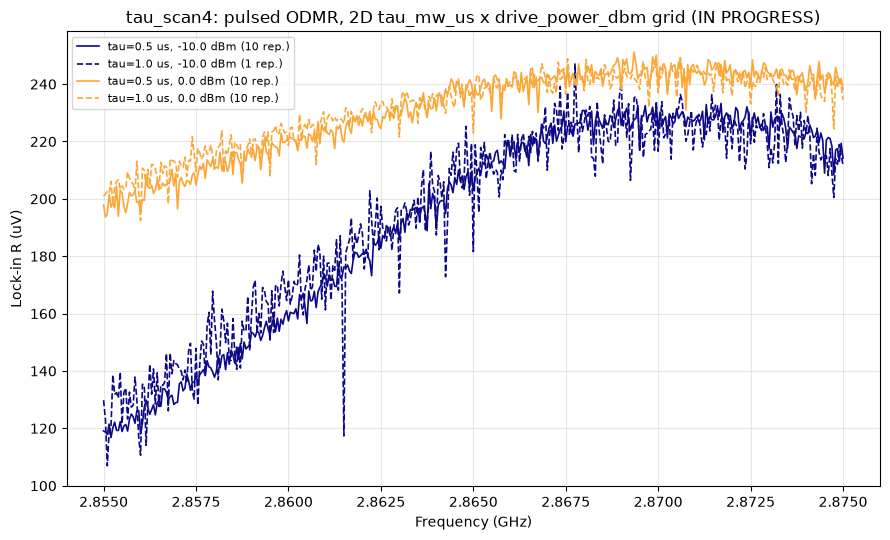

In [3]:
import glob
import re

name_ts4 = "tau_scan4"
run_path_ts4 = f"{DATA_DIR}/{name_ts4}"


def _tau_from_tag(tag):
    return float(tag.replace("p", ".").replace("us", ""))


def _power_from_tag(tag):
    if tag.startswith("m"):
        return -float(tag[1:-3].replace("p", "."))
    return float(tag[:-3].replace("p", "."))


pair_tags_ts4 = sorted(
    {re.search(r"_tau([0-9p]+us)_power([0-9a-zA-Z]+dBm)_repeat\d+_pulsed_odmr_x\.npy$", p).groups()
     for p in glob.glob(f"{run_path_ts4}/{name_ts4}_tau*_power*_repeat*_pulsed_odmr_x.npy")},
    key=lambda tp: (_power_from_tag(tp[1]), _tau_from_tag(tp[0])),
)
print(f"found (tau_mw_us, drive_power_dbm) pairs: "
      f"{[(_tau_from_tag(t), _power_from_tag(p)) for t, p in pair_tags_ts4]}")

grid_results_ts4 = {}
for tau_tag, power_tag in pair_tags_ts4:
    tau_mw_us = _tau_from_tag(tau_tag)
    power_dbm = _power_from_tag(power_tag)
    prefix_glob = f"{run_path_ts4}/{name_ts4}_tau{tau_tag}_power{power_tag}"

    repeat_indices = sorted(
        int(re.search(r"_repeat(\d+)_pulsed_odmr_x\.npy$", p).group(1))
        for p in glob.glob(f"{prefix_glob}_repeat*_pulsed_odmr_x.npy")
    )

    freqs_ref = None
    xs, ys = [], []
    for i in repeat_indices:
        prefix = f"{prefix_glob}_repeat{i}"
        freqs_i = np.load(f"{prefix}_pulsed_odmr_freqs_hz.npy")
        if freqs_ref is None:
            freqs_ref = freqs_i
        elif len(freqs_i) != len(freqs_ref) or not np.allclose(freqs_i, freqs_ref):
            print(f"  tau={tau_mw_us} us, power={power_dbm} dBm, repeat{i}: "
                  f"freqs_hz grid mismatch -- excluded")
            continue
        xs.append(np.load(f"{prefix}_pulsed_odmr_x.npy"))
        ys.append(np.load(f"{prefix}_pulsed_odmr_y.npy"))

    x_avg = np.mean(xs, axis=0)
    y_avg = np.mean(ys, axis=0)
    r_avg = np.sqrt(x_avg**2 + y_avg**2)
    grid_results_ts4[(tau_mw_us, power_dbm)] = dict(freqs_hz=freqs_ref, r=r_avg, n_repeats=len(xs))
    print(f"tau_mw={tau_mw_us} us, power={power_dbm} dBm: {len(xs)} repeats averaged, "
          f"{len(freqs_ref)} points, {freqs_ref.min()/1e9:.6f}-{freqs_ref.max()/1e9:.6f} GHz")

power_values_ts4 = sorted({p for _, p in grid_results_ts4})
tau_values_ts4 = sorted({t for t, _ in grid_results_ts4})
power_colors_ts4 = dict(zip(power_values_ts4, plt.cm.plasma(np.linspace(0, 0.8, max(len(power_values_ts4), 1)))))
tau_styles_ts4 = dict(zip(tau_values_ts4, ["-", "--", "-.", ":"] * 4))

fig, ax = plt.subplots(figsize=(9, 5.5))
for (tau_mw_us, power_dbm), d in sorted(grid_results_ts4.items(), key=lambda kv: (kv[0][1], kv[0][0])):
    ax.plot(d["freqs_hz"] / 1e9, d["r"] * 1e6, tau_styles_ts4[tau_mw_us],
            color=power_colors_ts4[power_dbm], lw=1.2, ms=3,
            label=f"tau={tau_mw_us} us, {power_dbm} dBm ({d['n_repeats']} rep.)")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_ts4}: pulsed ODMR, 2D tau_mw_us x drive_power_dbm grid (IN PROGRESS)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## tau_scan_5 (pulsed_odmr.py run-repeat, tau_mw_us_list) -- gain vs. tau_mw

Another `tau_mw_us_list`-only batch (no power grid), IN PROGRESS -- only
`tau_mw=2` us has completed repeats so far (8 repeats). Note this batch
uses a much larger `anchor_free_reps=800000` (10x `tau_scan1`/`tau_scan4`'s
80000) and a coarser `sensitivity_v=0.005` (10x `tau_scan1`'s 0.0002) --
different settings from the earlier tau scans, so don't directly compare
absolute R magnitudes across batches. Same auto-discovery pattern as
`tau_scan2` above (tau values discovered from disk, not hardcoded).

found tau_mw values: [2.0]
tau_mw=2.0 us: 8 repeats averaged, 565 points, 2.855000-2.883200 GHz


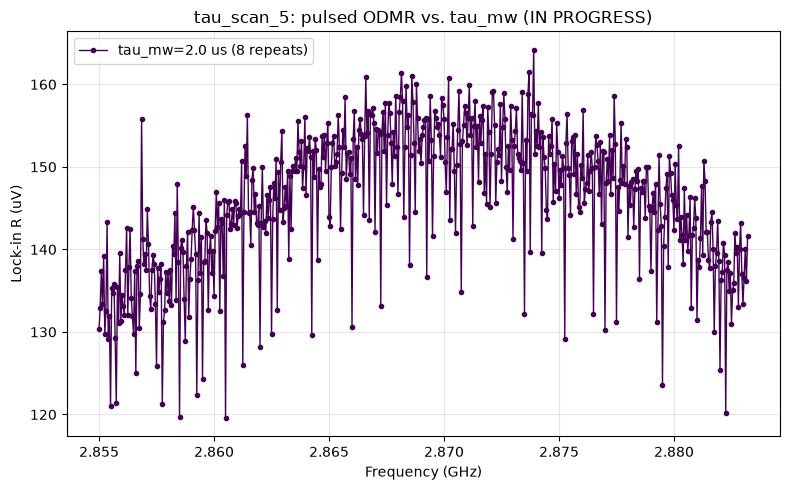

In [3]:
import glob
import re

name_ts5 = "tau_scan_5"
run_path_ts5 = f"{DATA_DIR}/{name_ts5}"


def _tau_tag(tau_mw_us):
    return f"{tau_mw_us:g}us".replace(".", "p")


def _tau_from_tag(tag):
    return float(tag.replace("p", ".").replace("us", ""))


tau_tags_ts5 = sorted(
    {re.search(r"_tau([0-9p]+us)_repeat\d+_pulsed_odmr_x\.npy$", p).group(1)
     for p in glob.glob(f"{run_path_ts5}/{name_ts5}_tau*_repeat*_pulsed_odmr_x.npy")},
    key=_tau_from_tag,
)
print(f"found tau_mw values: {[_tau_from_tag(t) for t in tau_tags_ts5]}")

tau_results_ts5 = {}
for tag in tau_tags_ts5:
    tau_mw_us = _tau_from_tag(tag)
    prefix_glob = f"{run_path_ts5}/{name_ts5}_tau{tag}"

    repeat_indices = sorted(
        int(re.search(r"_repeat(\d+)_pulsed_odmr_x\.npy$", p).group(1))
        for p in glob.glob(f"{prefix_glob}_repeat*_pulsed_odmr_x.npy")
    )

    freqs_ref = None
    xs, ys = [], []
    for i in repeat_indices:
        prefix = f"{prefix_glob}_repeat{i}"
        freqs_i = np.load(f"{prefix}_pulsed_odmr_freqs_hz.npy")
        if freqs_ref is None:
            freqs_ref = freqs_i
        elif len(freqs_i) != len(freqs_ref) or not np.allclose(freqs_i, freqs_ref):
            print(f"  tau={tau_mw_us} us, repeat{i}: freqs_hz grid mismatch -- excluded")
            continue
        xs.append(np.load(f"{prefix}_pulsed_odmr_x.npy"))
        ys.append(np.load(f"{prefix}_pulsed_odmr_y.npy"))

    x_avg = np.mean(xs, axis=0)
    y_avg = np.mean(ys, axis=0)
    r_avg = np.sqrt(x_avg**2 + y_avg**2)
    tau_results_ts5[tau_mw_us] = dict(freqs_hz=freqs_ref, r=r_avg, n_repeats=len(xs))
    print(f"tau_mw={tau_mw_us} us: {len(xs)} repeats averaged, "
          f"{len(freqs_ref)} points, {freqs_ref.min()/1e9:.6f}-{freqs_ref.max()/1e9:.6f} GHz")

fig, ax = plt.subplots(figsize=(8, 5))
tau_values_ts5 = sorted(tau_results_ts5)
colors = plt.cm.viridis(np.linspace(0, 0.85, max(len(tau_values_ts5), 1)))
for tau_mw_us, color in zip(tau_values_ts5, colors):
    d = tau_results_ts5[tau_mw_us]
    ax.plot(d["freqs_hz"] / 1e9, d["r"] * 1e6, "o-", ms=3, lw=1, color=color,
            label=f"tau_mw={tau_mw_us} us ({d['n_repeats']} repeats)")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_ts5}: pulsed ODMR vs. tau_mw (IN PROGRESS)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## tau_scan_6 (pulsed_odmr.py run-repeat, tau_mw_us_list) -- gain vs. tau_mw

Another `tau_mw_us_list`-only batch, IN PROGRESS -- only `tau_mw=4` us has
completed repeats so far (2 repeats). Yet another different sensitivity
setting (`sensitivity_v=0.02`, vs. `tau_scan_5`'s 0.005 and `tau_scan1`'s
0.0002/0.0005) -- don't compare absolute R magnitudes across batches. Same
auto-discovery pattern as `tau_scan2`/`tau_scan_5` above.

found tau_mw values: [4.0]
tau_mw=4.0 us: 2 repeats averaged, 485 points, 2.855000-2.879200 GHz


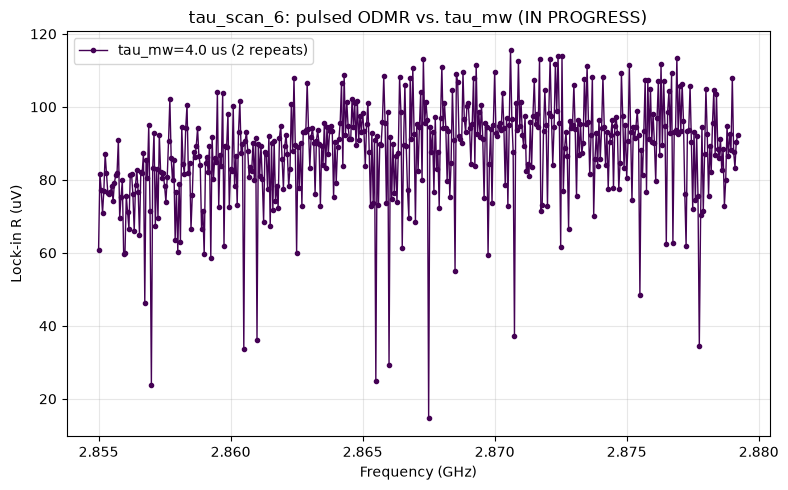

In [3]:
import glob
import re

name_ts6 = "tau_scan_6"
run_path_ts6 = f"{DATA_DIR}/{name_ts6}"


def _tau_tag(tau_mw_us):
    return f"{tau_mw_us:g}us".replace(".", "p")


def _tau_from_tag(tag):
    return float(tag.replace("p", ".").replace("us", ""))


tau_tags_ts6 = sorted(
    {re.search(r"_tau([0-9p]+us)_repeat\d+_pulsed_odmr_x\.npy$", p).group(1)
     for p in glob.glob(f"{run_path_ts6}/{name_ts6}_tau*_repeat*_pulsed_odmr_x.npy")},
    key=_tau_from_tag,
)
print(f"found tau_mw values: {[_tau_from_tag(t) for t in tau_tags_ts6]}")

tau_results_ts6 = {}
for tag in tau_tags_ts6:
    tau_mw_us = _tau_from_tag(tag)
    prefix_glob = f"{run_path_ts6}/{name_ts6}_tau{tag}"

    repeat_indices = sorted(
        int(re.search(r"_repeat(\d+)_pulsed_odmr_x\.npy$", p).group(1))
        for p in glob.glob(f"{prefix_glob}_repeat*_pulsed_odmr_x.npy")
    )

    freqs_ref = None
    xs, ys = [], []
    for i in repeat_indices:
        prefix = f"{prefix_glob}_repeat{i}"
        freqs_i = np.load(f"{prefix}_pulsed_odmr_freqs_hz.npy")
        if freqs_ref is None:
            freqs_ref = freqs_i
        elif len(freqs_i) != len(freqs_ref) or not np.allclose(freqs_i, freqs_ref):
            print(f"  tau={tau_mw_us} us, repeat{i}: freqs_hz grid mismatch -- excluded")
            continue
        xs.append(np.load(f"{prefix}_pulsed_odmr_x.npy"))
        ys.append(np.load(f"{prefix}_pulsed_odmr_y.npy"))

    x_avg = np.mean(xs, axis=0)
    y_avg = np.mean(ys, axis=0)
    r_avg = np.sqrt(x_avg**2 + y_avg**2)
    tau_results_ts6[tau_mw_us] = dict(freqs_hz=freqs_ref, r=r_avg, n_repeats=len(xs))
    print(f"tau_mw={tau_mw_us} us: {len(xs)} repeats averaged, "
          f"{len(freqs_ref)} points, {freqs_ref.min()/1e9:.6f}-{freqs_ref.max()/1e9:.6f} GHz")

fig, ax = plt.subplots(figsize=(8, 5))
tau_values_ts6 = sorted(tau_results_ts6)
colors = plt.cm.viridis(np.linspace(0, 0.85, max(len(tau_values_ts6), 1)))
for tau_mw_us, color in zip(tau_values_ts6, colors):
    d = tau_results_ts6[tau_mw_us]
    ax.plot(d["freqs_hz"] / 1e9, d["r"] * 1e6, "o-", ms=3, lw=1, color=color,
            label=f"tau_mw={tau_mw_us} us ({d['n_repeats']} repeats)")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_ts6}: pulsed ODMR vs. tau_mw (IN PROGRESS)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## tau_scan_7 (pulsed_odmr.py run-repeat, 2D tau_mw_us x drive_power_dbm grid)

A bigger 2D grid than `tau_scan4` -- 4 tau_mw_us values (0.5, 1, 2, 4 us) x
2 drive_power_dbm values (-10, -20 dBm), IN PROGRESS with just 1 repeat
completed per grid cell so far (8 cells total, all started). Same auto-
discovery and grouped-by-power/styled-by-tau plotting as `tau_scan4`'s
cell above.

found (tau_mw_us, drive_power_dbm) pairs: [(0.5, -20.0), (1.0, -20.0), (2.0, -20.0), (4.0, -20.0), (0.5, -10.0), (1.0, -10.0), (2.0, -10.0), (4.0, -10.0)]
tau_mw=0.5 us, power=-20.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=1.0 us, power=-20.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=2.0 us, power=-20.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=4.0 us, power=-20.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=0.5 us, power=-10.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=1.0 us, power=-10.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=2.0 us, power=-10.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=4.0 us, power=-10.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz


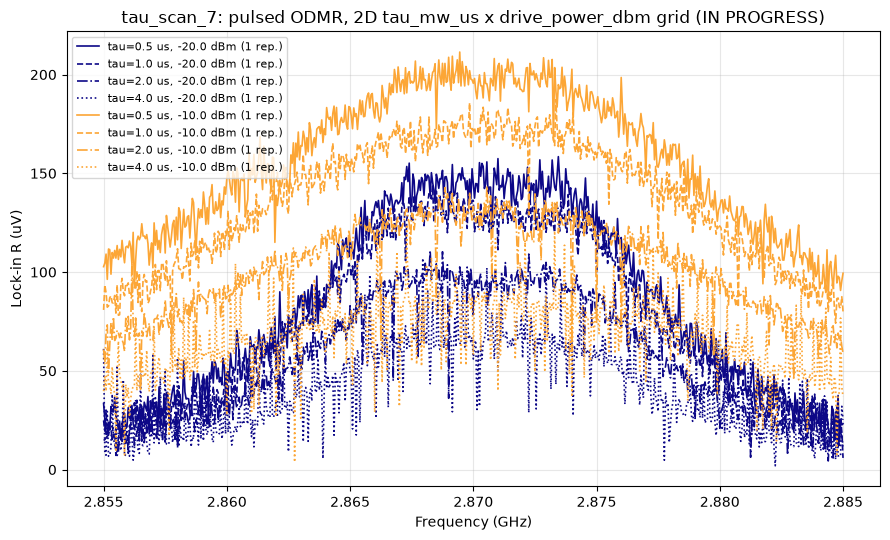

In [3]:
import glob
import re

name_ts7 = "tau_scan_7"
run_path_ts7 = f"{DATA_DIR}/{name_ts7}"


def _tau_from_tag(tag):
    return float(tag.replace("p", ".").replace("us", ""))


def _power_from_tag(tag):
    if tag.startswith("m"):
        return -float(tag[1:-3].replace("p", "."))
    return float(tag[:-3].replace("p", "."))


pair_tags_ts7 = sorted(
    {re.search(r"_tau([0-9p]+us)_power([0-9a-zA-Z]+dBm)_repeat\d+_pulsed_odmr_x\.npy$", p).groups()
     for p in glob.glob(f"{run_path_ts7}/{name_ts7}_tau*_power*_repeat*_pulsed_odmr_x.npy")},
    key=lambda tp: (_power_from_tag(tp[1]), _tau_from_tag(tp[0])),
)
print(f"found (tau_mw_us, drive_power_dbm) pairs: "
      f"{[(_tau_from_tag(t), _power_from_tag(p)) for t, p in pair_tags_ts7]}")

grid_results_ts7 = {}
for tau_tag, power_tag in pair_tags_ts7:
    tau_mw_us = _tau_from_tag(tau_tag)
    power_dbm = _power_from_tag(power_tag)
    prefix_glob = f"{run_path_ts7}/{name_ts7}_tau{tau_tag}_power{power_tag}"

    repeat_indices = sorted(
        int(re.search(r"_repeat(\d+)_pulsed_odmr_x\.npy$", p).group(1))
        for p in glob.glob(f"{prefix_glob}_repeat*_pulsed_odmr_x.npy")
    )

    freqs_ref = None
    xs, ys = [], []
    for i in repeat_indices:
        prefix = f"{prefix_glob}_repeat{i}"
        freqs_i = np.load(f"{prefix}_pulsed_odmr_freqs_hz.npy")
        if freqs_ref is None:
            freqs_ref = freqs_i
        elif len(freqs_i) != len(freqs_ref) or not np.allclose(freqs_i, freqs_ref):
            print(f"  tau={tau_mw_us} us, power={power_dbm} dBm, repeat{i}: "
                  f"freqs_hz grid mismatch -- excluded")
            continue
        xs.append(np.load(f"{prefix}_pulsed_odmr_x.npy"))
        ys.append(np.load(f"{prefix}_pulsed_odmr_y.npy"))

    x_avg = np.mean(xs, axis=0)
    y_avg = np.mean(ys, axis=0)
    r_avg = np.sqrt(x_avg**2 + y_avg**2)
    grid_results_ts7[(tau_mw_us, power_dbm)] = dict(freqs_hz=freqs_ref, r=r_avg, n_repeats=len(xs))
    print(f"tau_mw={tau_mw_us} us, power={power_dbm} dBm: {len(xs)} repeats averaged, "
          f"{len(freqs_ref)} points, {freqs_ref.min()/1e9:.6f}-{freqs_ref.max()/1e9:.6f} GHz")

power_values_ts7 = sorted({p for _, p in grid_results_ts7})
tau_values_ts7 = sorted({t for t, _ in grid_results_ts7})
power_colors_ts7 = dict(zip(power_values_ts7, plt.cm.plasma(np.linspace(0, 0.8, max(len(power_values_ts7), 1)))))
tau_styles_ts7 = dict(zip(tau_values_ts7, ["-", "--", "-.", ":"] * 4))

fig, ax = plt.subplots(figsize=(9, 5.5))
for (tau_mw_us, power_dbm), d in sorted(grid_results_ts7.items(), key=lambda kv: (kv[0][1], kv[0][0])):
    ax.plot(d["freqs_hz"] / 1e9, d["r"] * 1e6, tau_styles_ts7[tau_mw_us],
            color=power_colors_ts7[power_dbm], lw=1.2, ms=3,
            label=f"tau={tau_mw_us} us, {power_dbm} dBm ({d['n_repeats']} rep.)")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_ts7}: pulsed ODMR, 2D tau_mw_us x drive_power_dbm grid (IN PROGRESS)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## tau_scan_8 (pulsed_odmr.py run-repeat, 2D tau_mw_us x drive_power_dbm grid)

Same 4 tau_mw_us values as `tau_scan_7` (0.5, 1, 2, 4 us), but only one
drive_power_dbm this time (-25 dBm, even lower than `tau_scan_7`'s -10/-20
dBm) -- IN PROGRESS, 1 repeat completed per cell so far (4 cells total).
Same auto-discovery/plotting code as `tau_scan_7`'s cell above.

found (tau_mw_us, drive_power_dbm) pairs: [(0.5, -25.0), (1.0, -25.0), (2.0, -25.0), (4.0, -25.0)]
tau_mw=0.5 us, power=-25.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=1.0 us, power=-25.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=2.0 us, power=-25.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=4.0 us, power=-25.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz


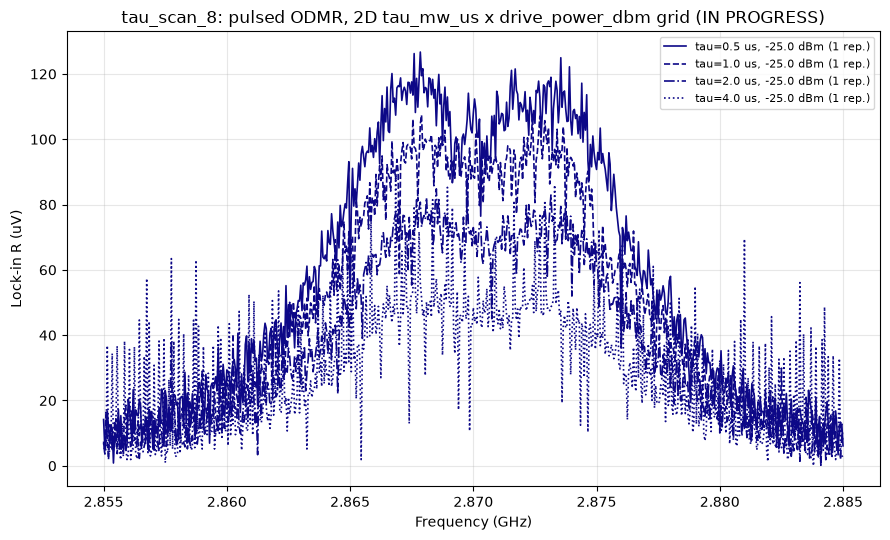

In [3]:
import glob
import re

name_ts8 = "tau_scan_8"
run_path_ts8 = f"{DATA_DIR}/{name_ts8}"


def _tau_from_tag(tag):
    return float(tag.replace("p", ".").replace("us", ""))


def _power_from_tag(tag):
    if tag.startswith("m"):
        return -float(tag[1:-3].replace("p", "."))
    return float(tag[:-3].replace("p", "."))


pair_tags_ts8 = sorted(
    {re.search(r"_tau([0-9p]+us)_power([0-9a-zA-Z]+dBm)_repeat\d+_pulsed_odmr_x\.npy$", p).groups()
     for p in glob.glob(f"{run_path_ts8}/{name_ts8}_tau*_power*_repeat*_pulsed_odmr_x.npy")},
    key=lambda tp: (_power_from_tag(tp[1]), _tau_from_tag(tp[0])),
)
print(f"found (tau_mw_us, drive_power_dbm) pairs: "
      f"{[(_tau_from_tag(t), _power_from_tag(p)) for t, p in pair_tags_ts8]}")

grid_results_ts8 = {}
for tau_tag, power_tag in pair_tags_ts8:
    tau_mw_us = _tau_from_tag(tau_tag)
    power_dbm = _power_from_tag(power_tag)
    prefix_glob = f"{run_path_ts8}/{name_ts8}_tau{tau_tag}_power{power_tag}"

    repeat_indices = sorted(
        int(re.search(r"_repeat(\d+)_pulsed_odmr_x\.npy$", p).group(1))
        for p in glob.glob(f"{prefix_glob}_repeat*_pulsed_odmr_x.npy")
    )

    freqs_ref = None
    xs, ys = [], []
    for i in repeat_indices:
        prefix = f"{prefix_glob}_repeat{i}"
        freqs_i = np.load(f"{prefix}_pulsed_odmr_freqs_hz.npy")
        if freqs_ref is None:
            freqs_ref = freqs_i
        elif len(freqs_i) != len(freqs_ref) or not np.allclose(freqs_i, freqs_ref):
            print(f"  tau={tau_mw_us} us, power={power_dbm} dBm, repeat{i}: "
                  f"freqs_hz grid mismatch -- excluded")
            continue
        xs.append(np.load(f"{prefix}_pulsed_odmr_x.npy"))
        ys.append(np.load(f"{prefix}_pulsed_odmr_y.npy"))

    x_avg = np.mean(xs, axis=0)
    y_avg = np.mean(ys, axis=0)
    r_avg = np.sqrt(x_avg**2 + y_avg**2)
    grid_results_ts8[(tau_mw_us, power_dbm)] = dict(freqs_hz=freqs_ref, r=r_avg, n_repeats=len(xs))
    print(f"tau_mw={tau_mw_us} us, power={power_dbm} dBm: {len(xs)} repeats averaged, "
          f"{len(freqs_ref)} points, {freqs_ref.min()/1e9:.6f}-{freqs_ref.max()/1e9:.6f} GHz")

power_values_ts8 = sorted({p for _, p in grid_results_ts8})
tau_values_ts8 = sorted({t for t, _ in grid_results_ts8})
power_colors_ts8 = dict(zip(power_values_ts8, plt.cm.plasma(np.linspace(0, 0.8, max(len(power_values_ts8), 1)))))
tau_styles_ts8 = dict(zip(tau_values_ts8, ["-", "--", "-.", ":"] * 4))

fig, ax = plt.subplots(figsize=(9, 5.5))
for (tau_mw_us, power_dbm), d in sorted(grid_results_ts8.items(), key=lambda kv: (kv[0][1], kv[0][0])):
    ax.plot(d["freqs_hz"] / 1e9, d["r"] * 1e6, tau_styles_ts8[tau_mw_us],
            color=power_colors_ts8[power_dbm], lw=1.2, ms=3,
            label=f"tau={tau_mw_us} us, {power_dbm} dBm ({d['n_repeats']} rep.)")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_ts8}: pulsed ODMR, 2D tau_mw_us x drive_power_dbm grid (IN PROGRESS)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## tau_scan_9 (pulsed_odmr.py run-repeat, 2D tau_mw_us x drive_power_dbm grid)

Just starting -- only `tau_mw=0.5` us has data so far, at two drive_power_
dbm values (-25, -30 dBm, extending `tau_scan_8`'s -25 dBm even lower), 1
repeat each. Same auto-discovery/plotting code as `tau_scan_7`/`tau_scan_8`
above -- will pick up more tau_mw values and repeats as the batch
continues.

found (tau_mw_us, drive_power_dbm) pairs: [(0.5, -30.0), (0.5, -25.0)]
tau_mw=0.5 us, power=-30.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=0.5 us, power=-25.0 dBm: 1 repeats averaged, 50 points, 2.855000-2.857450 GHz


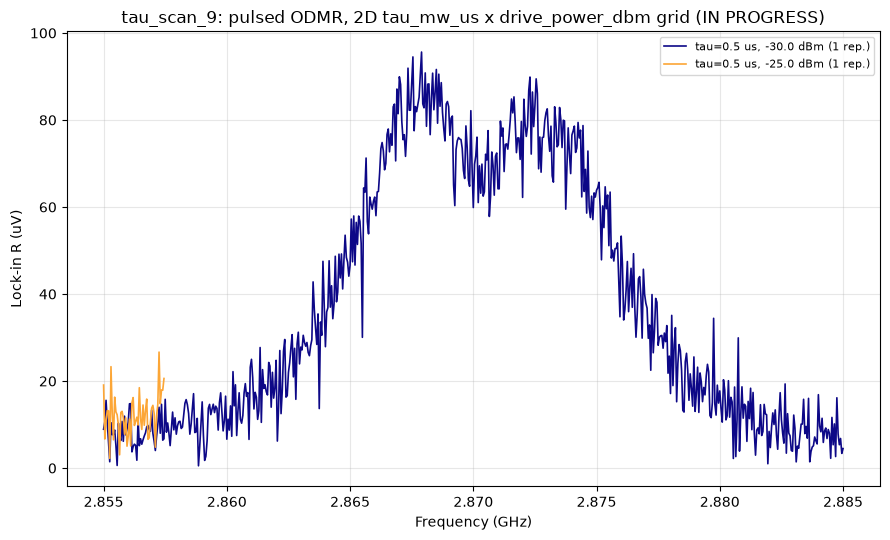

In [3]:
import glob
import re

name_ts9 = "tau_scan_9"
run_path_ts9 = f"{DATA_DIR}/{name_ts9}"


def _tau_from_tag(tag):
    return float(tag.replace("p", ".").replace("us", ""))


def _power_from_tag(tag):
    if tag.startswith("m"):
        return -float(tag[1:-3].replace("p", "."))
    return float(tag[:-3].replace("p", "."))


pair_tags_ts9 = sorted(
    {re.search(r"_tau([0-9p]+us)_power([0-9a-zA-Z]+dBm)_repeat\d+_pulsed_odmr_x\.npy$", p).groups()
     for p in glob.glob(f"{run_path_ts9}/{name_ts9}_tau*_power*_repeat*_pulsed_odmr_x.npy")},
    key=lambda tp: (_power_from_tag(tp[1]), _tau_from_tag(tp[0])),
)
print(f"found (tau_mw_us, drive_power_dbm) pairs: "
      f"{[(_tau_from_tag(t), _power_from_tag(p)) for t, p in pair_tags_ts9]}")

grid_results_ts9 = {}
for tau_tag, power_tag in pair_tags_ts9:
    tau_mw_us = _tau_from_tag(tau_tag)
    power_dbm = _power_from_tag(power_tag)
    prefix_glob = f"{run_path_ts9}/{name_ts9}_tau{tau_tag}_power{power_tag}"

    repeat_indices = sorted(
        int(re.search(r"_repeat(\d+)_pulsed_odmr_x\.npy$", p).group(1))
        for p in glob.glob(f"{prefix_glob}_repeat*_pulsed_odmr_x.npy")
    )

    freqs_ref = None
    xs, ys = [], []
    for i in repeat_indices:
        prefix = f"{prefix_glob}_repeat{i}"
        freqs_i = np.load(f"{prefix}_pulsed_odmr_freqs_hz.npy")
        if freqs_ref is None:
            freqs_ref = freqs_i
        elif len(freqs_i) != len(freqs_ref) or not np.allclose(freqs_i, freqs_ref):
            print(f"  tau={tau_mw_us} us, power={power_dbm} dBm, repeat{i}: "
                  f"freqs_hz grid mismatch -- excluded")
            continue
        xs.append(np.load(f"{prefix}_pulsed_odmr_x.npy"))
        ys.append(np.load(f"{prefix}_pulsed_odmr_y.npy"))

    x_avg = np.mean(xs, axis=0)
    y_avg = np.mean(ys, axis=0)
    r_avg = np.sqrt(x_avg**2 + y_avg**2)
    grid_results_ts9[(tau_mw_us, power_dbm)] = dict(freqs_hz=freqs_ref, r=r_avg, n_repeats=len(xs))
    print(f"tau_mw={tau_mw_us} us, power={power_dbm} dBm: {len(xs)} repeats averaged, "
          f"{len(freqs_ref)} points, {freqs_ref.min()/1e9:.6f}-{freqs_ref.max()/1e9:.6f} GHz")

power_values_ts9 = sorted({p for _, p in grid_results_ts9})
tau_values_ts9 = sorted({t for t, _ in grid_results_ts9})
power_colors_ts9 = dict(zip(power_values_ts9, plt.cm.plasma(np.linspace(0, 0.8, max(len(power_values_ts9), 1)))))
tau_styles_ts9 = dict(zip(tau_values_ts9, ["-", "--", "-.", ":"] * 4))

fig, ax = plt.subplots(figsize=(9, 5.5))
for (tau_mw_us, power_dbm), d in sorted(grid_results_ts9.items(), key=lambda kv: (kv[0][1], kv[0][0])):
    ax.plot(d["freqs_hz"] / 1e9, d["r"] * 1e6, tau_styles_ts9[tau_mw_us],
            color=power_colors_ts9[power_dbm], lw=1.2, ms=3,
            label=f"tau={tau_mw_us} us, {power_dbm} dBm ({d['n_repeats']} rep.)")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_ts9}: pulsed ODMR, 2D tau_mw_us x drive_power_dbm grid (IN PROGRESS)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## All complete tau_mw=0.5 us traces, 2.855-2.885 GHz, by power

Surveyed `tau_scan_7`/`tau_scan_8`/`tau_scan_9` under `D:/pulsed_odmr` for
`tau_mw_us=0.5` batches with a full (non-truncated) 601-point sweep across
the SAME 2.855-2.885 GHz range. Excludes `tau_scan1`/`tau_scan4` (narrower/
offset ranges -- 2.860-2.880 and 2.855-2.875 respectively -- not directly
comparable on the same frequency axis) and `tau_scan_9`'s `-25 dBm` cell
(only 50/601 points, still mid-sweep). 4 qualifying traces, one power level
each.

tau_scan_7/tau_scan_7_tau0p5us_powerm10dBm: power=-10.0 dBm, 1 repeats, 601 points, 2.855000-2.885000 GHz
tau_scan_7/tau_scan_7_tau0p5us_powerm20dBm: power=-20.0 dBm, 1 repeats, 601 points, 2.855000-2.885000 GHz
tau_scan_8/tau_scan_8_tau0p5us_powerm25dBm: power=-25.0 dBm, 1 repeats, 601 points, 2.855000-2.885000 GHz
tau_scan_9/tau_scan_9_tau0p5us_powerm30dBm: power=-30.0 dBm, 1 repeats, 601 points, 2.855000-2.885000 GHz


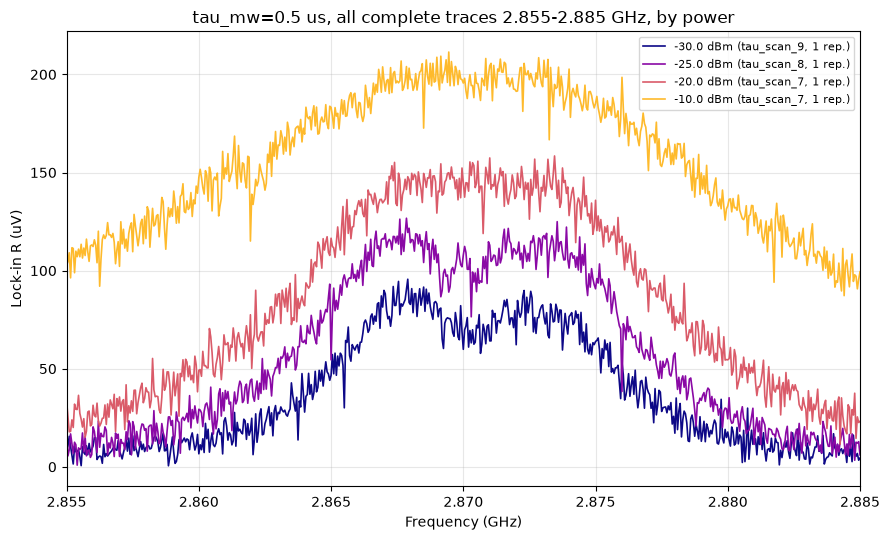

In [3]:
TAU05_TRACES = [
    dict(folder="tau_scan_7", prefix="tau_scan_7_tau0p5us_powerm10dBm", power_dbm=-10.0, n_repeats=1),
    dict(folder="tau_scan_7", prefix="tau_scan_7_tau0p5us_powerm20dBm", power_dbm=-20.0, n_repeats=1),
    dict(folder="tau_scan_8", prefix="tau_scan_8_tau0p5us_powerm25dBm", power_dbm=-25.0, n_repeats=1),
    dict(folder="tau_scan_9", prefix="tau_scan_9_tau0p5us_powerm30dBm", power_dbm=-30.0, n_repeats=1),
]

for trace in TAU05_TRACES:
    run_path = f"{DATA_DIR}/{trace['folder']}"
    xs, ys, freqs_ref = [], [], None
    for i in range(trace["n_repeats"]):
        prefix = f"{run_path}/{trace['prefix']}_repeat{i}"
        freqs_i = np.load(f"{prefix}_pulsed_odmr_freqs_hz.npy")
        if freqs_ref is None:
            freqs_ref = freqs_i
        xs.append(np.load(f"{prefix}_pulsed_odmr_x.npy"))
        ys.append(np.load(f"{prefix}_pulsed_odmr_y.npy"))
    x_avg = np.mean(xs, axis=0)
    y_avg = np.mean(ys, axis=0)
    trace["freqs_hz"] = freqs_ref
    trace["r"] = np.sqrt(x_avg**2 + y_avg**2)
    print(f"{trace['folder']}/{trace['prefix']}: power={trace['power_dbm']} dBm, "
          f"{trace['n_repeats']} repeats, {len(freqs_ref)} points, "
          f"{freqs_ref.min()/1e9:.6f}-{freqs_ref.max()/1e9:.6f} GHz")

power_values_05 = sorted({t["power_dbm"] for t in TAU05_TRACES})
power_colors_05 = dict(zip(power_values_05, plt.cm.plasma(np.linspace(0, 0.85, len(power_values_05)))))

fig, ax = plt.subplots(figsize=(9, 5.5))
for trace in sorted(TAU05_TRACES, key=lambda t: t["power_dbm"]):
    ax.plot(trace["freqs_hz"] / 1e9, trace["r"] * 1e6, lw=1.2,
            color=power_colors_05[trace["power_dbm"]],
            label=f"{trace['power_dbm']} dBm ({trace['folder']}, {trace['n_repeats']} rep.)")

ax.set_xlim(2.855, 2.885)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title("tau_mw=0.5 us, all complete traces 2.855-2.885 GHz, by power")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## tau_scan_15 (pulsed_odmr.py run-repeat, 2D tau_mw_us x drive_power_dbm grid)

Much shorter tau_mw_us values than any earlier tau scan -- 0.05, 0.1, 0.2 us
(vs. 0.5-4 us before) -- x 3 drive_power_dbm values (0, -25, -40 dBm), IN
PROGRESS with 1 repeat completed per cell so far (9 cells total, all
started). Same auto-discovery/plotting code as `tau_scan_7`/`tau_scan_8`/
`tau_scan_9` above.

found (tau_mw_us, drive_power_dbm) pairs: [(0.05, -40.0), (0.1, -40.0), (0.2, -40.0), (0.05, -25.0), (0.1, -25.0), (0.2, -25.0), (0.05, 0.0), (0.1, 0.0), (0.2, 0.0)]
tau_mw=0.05 us, power=-40.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=0.1 us, power=-40.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=0.2 us, power=-40.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=0.05 us, power=-25.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=0.1 us, power=-25.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=0.2 us, power=-25.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=0.05 us, power=0.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=0.1 us, power=0.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz
tau_mw=0.2 us, power=0.0 dBm: 1 repeats averaged, 601 points, 2.855000-2.885000 GHz


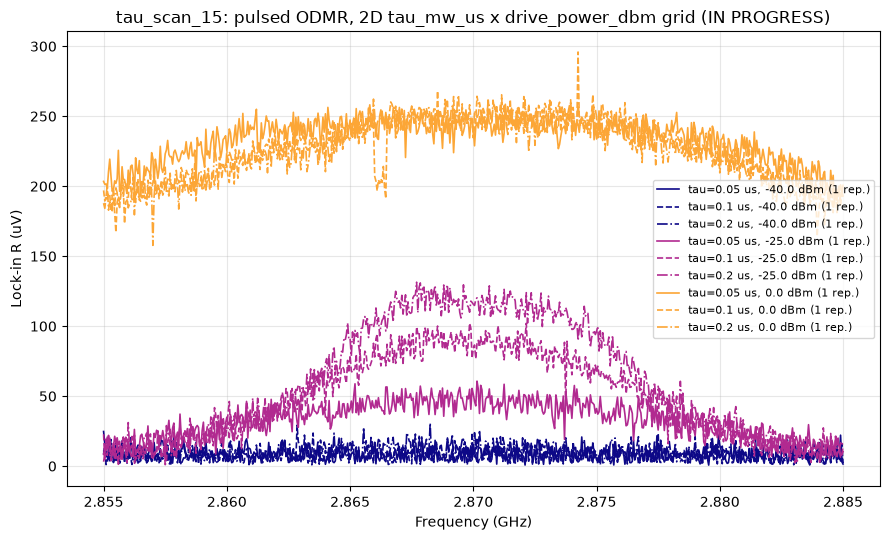

In [3]:
import glob
import re

name_ts15 = "tau_scan_15"
run_path_ts15 = f"{DATA_DIR}/{name_ts15}"


def _tau_from_tag(tag):
    return float(tag.replace("p", ".").replace("us", ""))


def _power_from_tag(tag):
    if tag.startswith("m"):
        return -float(tag[1:-3].replace("p", "."))
    return float(tag[:-3].replace("p", "."))


pair_tags_ts15 = sorted(
    {re.search(r"_tau([0-9p]+us)_power([0-9a-zA-Z]+dBm)_repeat\d+_pulsed_odmr_x\.npy$", p).groups()
     for p in glob.glob(f"{run_path_ts15}/{name_ts15}_tau*_power*_repeat*_pulsed_odmr_x.npy")},
    key=lambda tp: (_power_from_tag(tp[1]), _tau_from_tag(tp[0])),
)
print(f"found (tau_mw_us, drive_power_dbm) pairs: "
      f"{[(_tau_from_tag(t), _power_from_tag(p)) for t, p in pair_tags_ts15]}")

grid_results_ts15 = {}
for tau_tag, power_tag in pair_tags_ts15:
    tau_mw_us = _tau_from_tag(tau_tag)
    power_dbm = _power_from_tag(power_tag)
    prefix_glob = f"{run_path_ts15}/{name_ts15}_tau{tau_tag}_power{power_tag}"

    repeat_indices = sorted(
        int(re.search(r"_repeat(\d+)_pulsed_odmr_x\.npy$", p).group(1))
        for p in glob.glob(f"{prefix_glob}_repeat*_pulsed_odmr_x.npy")
    )

    freqs_ref = None
    xs, ys = [], []
    for i in repeat_indices:
        prefix = f"{prefix_glob}_repeat{i}"
        freqs_i = np.load(f"{prefix}_pulsed_odmr_freqs_hz.npy")
        if freqs_ref is None:
            freqs_ref = freqs_i
        elif len(freqs_i) != len(freqs_ref) or not np.allclose(freqs_i, freqs_ref):
            print(f"  tau={tau_mw_us} us, power={power_dbm} dBm, repeat{i}: "
                  f"freqs_hz grid mismatch -- excluded")
            continue
        xs.append(np.load(f"{prefix}_pulsed_odmr_x.npy"))
        ys.append(np.load(f"{prefix}_pulsed_odmr_y.npy"))

    x_avg = np.mean(xs, axis=0)
    y_avg = np.mean(ys, axis=0)
    r_avg = np.sqrt(x_avg**2 + y_avg**2)
    grid_results_ts15[(tau_mw_us, power_dbm)] = dict(freqs_hz=freqs_ref, r=r_avg, n_repeats=len(xs))
    print(f"tau_mw={tau_mw_us} us, power={power_dbm} dBm: {len(xs)} repeats averaged, "
          f"{len(freqs_ref)} points, {freqs_ref.min()/1e9:.6f}-{freqs_ref.max()/1e9:.6f} GHz")

power_values_ts15 = sorted({p for _, p in grid_results_ts15})
tau_values_ts15 = sorted({t for t, _ in grid_results_ts15})
power_colors_ts15 = dict(zip(power_values_ts15, plt.cm.plasma(np.linspace(0, 0.8, max(len(power_values_ts15), 1)))))
tau_styles_ts15 = dict(zip(tau_values_ts15, ["-", "--", "-.", ":"] * 4))

fig, ax = plt.subplots(figsize=(9, 5.5))
for (tau_mw_us, power_dbm), d in sorted(grid_results_ts15.items(), key=lambda kv: (kv[0][1], kv[0][0])):
    ax.plot(d["freqs_hz"] / 1e9, d["r"] * 1e6, tau_styles_ts15[tau_mw_us],
            color=power_colors_ts15[power_dbm], lw=1.2, ms=3,
            label=f"tau={tau_mw_us} us, {power_dbm} dBm ({d['n_repeats']} rep.)")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_ts15}: pulsed ODMR, 2D tau_mw_us x drive_power_dbm grid (IN PROGRESS)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## tau_scan_15/16/17: heatmap of max R vs. tau_mw / drive_power_dbm

Combines all three 2D-grid batches into one heatmap -- x-axis tau_mw_us
(union across all three, 0.02-64 us), y-axis drive_power_dbm, color = max
R over that cell's frequency sweep (1 repeat each, all still IN PROGRESS).
`tau_scan_15`'s `0 dBm` power level is EXCLUDED per instruction (those
runs are incomplete). Missing (tau, power) combinations show as blank
cells.

**Found while building this**: `reference_unlock`-flagged points scale
sharply with tau_mw, independent of power -- ~5-7% at tau=8 us, ~15-35% at
16/32 us, up to 60-64% at tau=64 us (checked across every power level in
`tau_scan_17`). A single unlock-flagged point can be a severely corrupted
reading (e.g. one `tau=64us, -10dBm` point read 255 uV against a ~3 uV
median -- a >90x outlier), which blew out an early version of this heatmap's
`tau=64us` column into a false bright band. Fixed by excluding unlock-
flagged points from the max-R calculation below, same convention as every
other fit/stat in this notebook. The unlock-fraction-vs-tau trend itself is
a real, separate finding worth investigating (see notes.md) -- probably
related to the same trigger-period/anchor_free_reps timing sensitivity
already documented there, now appearing to also scale with tau_mw itself,
not just anchor_free_reps.

cells with >10% reference_unlock points (max-R still computed from the remaining good points, but treat these as less reliable):
  tau=16.0 us, power=-40.0 dBm: 15% unlocked
  tau=16.0 us, power=-30.0 dBm: 18% unlocked
  tau=16.0 us, power=-25.0 dBm: 17% unlocked
  tau=16.0 us, power=-20.0 dBm: 19% unlocked
  tau=16.0 us, power=-10.0 dBm: 19% unlocked
  tau=16.0 us, power=-5.0 dBm: 18% unlocked
  tau=32.0 us, power=-40.0 dBm: 35% unlocked
  tau=32.0 us, power=-30.0 dBm: 31% unlocked
  tau=32.0 us, power=-25.0 dBm: 32% unlocked
  tau=32.0 us, power=-20.0 dBm: 31% unlocked
  tau=32.0 us, power=-10.0 dBm: 32% unlocked
  tau=32.0 us, power=-5.0 dBm: 29% unlocked
  tau=64.0 us, power=-30.0 dBm: 63% unlocked
  tau=64.0 us, power=-20.0 dBm: 64% unlocked
  tau=64.0 us, power=-10.0 dBm: 60% unlocked
  tau=64.0 us, power=-5.0 dBm: 62% unlocked


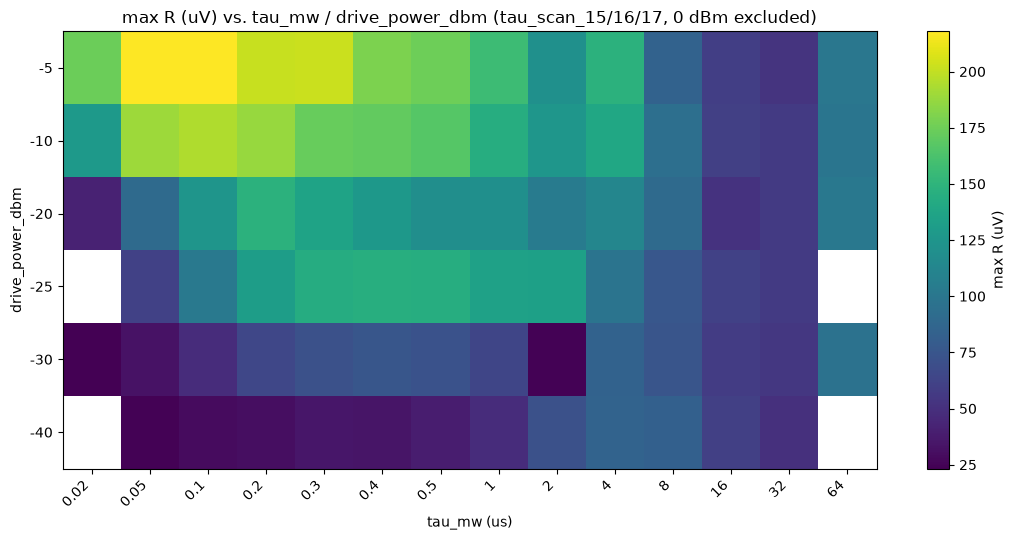

80 (tau, power) cells plotted, 14 tau values x 6 power values = 84 possible cells


In [3]:
import glob
import re

def _tau_from_tag(tag):
    return float(tag.replace("p", ".").replace("us", ""))


def _power_from_tag(tag):
    if tag.startswith("m"):
        return -float(tag[1:-3].replace("p", "."))
    return float(tag[:-3].replace("p", "."))


SCAN_NAMES = ["tau_scan_15", "tau_scan_16", "tau_scan_17"]
EXCLUDE_POWERS_DBM = {0.0}  # tau_scan_15's 0 dBm cells are incomplete

max_r_grid = {}
for scan_name in SCAN_NAMES:
    run_path = f"{DATA_DIR}/{scan_name}"
    pair_tags = sorted(
        {re.search(r"_tau([0-9p]+us)_power([0-9a-zA-Z]+dBm)_repeat\d+_pulsed_odmr_x\.npy$", p).groups()
         for p in glob.glob(f"{run_path}/{scan_name}_tau*_power*_repeat*_pulsed_odmr_x.npy")}
    )
    for tau_tag, power_tag in pair_tags:
        tau_mw_us = _tau_from_tag(tau_tag)
        power_dbm = _power_from_tag(power_tag)
        if power_dbm in EXCLUDE_POWERS_DBM:
            continue
        prefix_glob = f"{run_path}/{scan_name}_tau{tau_tag}_power{power_tag}"
        repeat_indices = sorted(
            int(re.search(r"_repeat(\d+)_pulsed_odmr_x\.npy$", p).group(1))
            for p in glob.glob(f"{prefix_glob}_repeat*_pulsed_odmr_x.npy")
        )
        xs, ys, unlocks = [], [], []
        for i in repeat_indices:
            prefix = f"{prefix_glob}_repeat{i}"
            xs.append(np.load(f"{prefix}_pulsed_odmr_x.npy"))
            ys.append(np.load(f"{prefix}_pulsed_odmr_y.npy"))
            unlocks.append(np.load(f"{prefix}_pulsed_odmr_reference_unlock.npy"))
        x_avg = np.mean(xs, axis=0)
        y_avg = np.mean(ys, axis=0)
        r_avg = np.sqrt(x_avg**2 + y_avg**2)
        # A point flagged reference_unlock in ANY repeat can be a severely
        # corrupted reading (not just noisy) -- exclude before taking max,
        # same convention as every other fit/stat in this notebook.
        unlock_any = np.any(unlocks, axis=0)
        good = ~unlock_any
        if not good.any():
            print(f"  {scan_name} tau={tau_mw_us} us, power={power_dbm} dBm: "
                  f"ALL points unlock-flagged -- skipped entirely")
            continue
        key = (tau_mw_us, power_dbm)
        # If the SAME (tau, power) pair appears in more than one scan
        # (shouldn't happen here, but be defensive), keep the one with
        # more repeats rather than silently overwriting.
        if key not in max_r_grid or len(xs) > max_r_grid[key][1]:
            max_r_grid[key] = (r_avg[good].max(), len(xs), scan_name,
                                unlock_any.sum() / len(unlock_any))

tau_values = sorted({t for t, _ in max_r_grid})
power_values = sorted({p for _, p in max_r_grid})

grid = np.full((len(power_values), len(tau_values)), np.nan)
unlock_frac_grid = np.full((len(power_values), len(tau_values)), np.nan)
for (tau_mw_us, power_dbm), (max_r, n_rep, scan_name, unlock_frac) in max_r_grid.items():
    i = power_values.index(power_dbm)
    j = tau_values.index(tau_mw_us)
    grid[i, j] = max_r * 1e6  # uV
    unlock_frac_grid[i, j] = unlock_frac

high_unlock = [(tau_values[j], power_values[i], unlock_frac_grid[i, j])
               for i in range(len(power_values)) for j in range(len(tau_values))
               if unlock_frac_grid[i, j] > 0.1]
if high_unlock:
    print("cells with >10% reference_unlock points (max-R still computed "
          "from the remaining good points, but treat these as less "
          "reliable):")
    for tau_mw_us, power_dbm, frac in sorted(high_unlock):
        print(f"  tau={tau_mw_us} us, power={power_dbm} dBm: "
              f"{frac*100:.0f}% unlocked")

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(grid, aspect="auto", origin="lower", cmap="viridis",
                extent=[-0.5, len(tau_values) - 0.5, -0.5, len(power_values) - 0.5])
ax.set_xticks(range(len(tau_values)))
ax.set_xticklabels([f"{t:g}" for t in tau_values], rotation=45, ha="right")
ax.set_yticks(range(len(power_values)))
ax.set_yticklabels([f"{p:g}" for p in power_values])
ax.set_xlabel("tau_mw (us)")
ax.set_ylabel("drive_power_dbm")
ax.set_title("max R (uV) vs. tau_mw / drive_power_dbm (tau_scan_15/16/17, 0 dBm excluded)")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("max R (uV)")
plt.tight_layout()
plt.show()

print(f"{len(max_r_grid)} (tau, power) cells plotted, "
      f"{len(tau_values)} tau values x {len(power_values)} power values "
      f"= {len(tau_values) * len(power_values)} possible cells")

## Same heatmap, each power row normalized to its own max R

Reuses `grid` from the cell above (max R vs. tau_mw/drive_power_dbm,
unlock-filtered) -- divides each power row by its own max across all
tau_mw values, so every row peaks at 1.0. Isolates the SHAPE of the
tau_mw dependence at each power level from the overall power-scaling of
the signal (which otherwise dominates the unnormalized heatmap's color
scale).

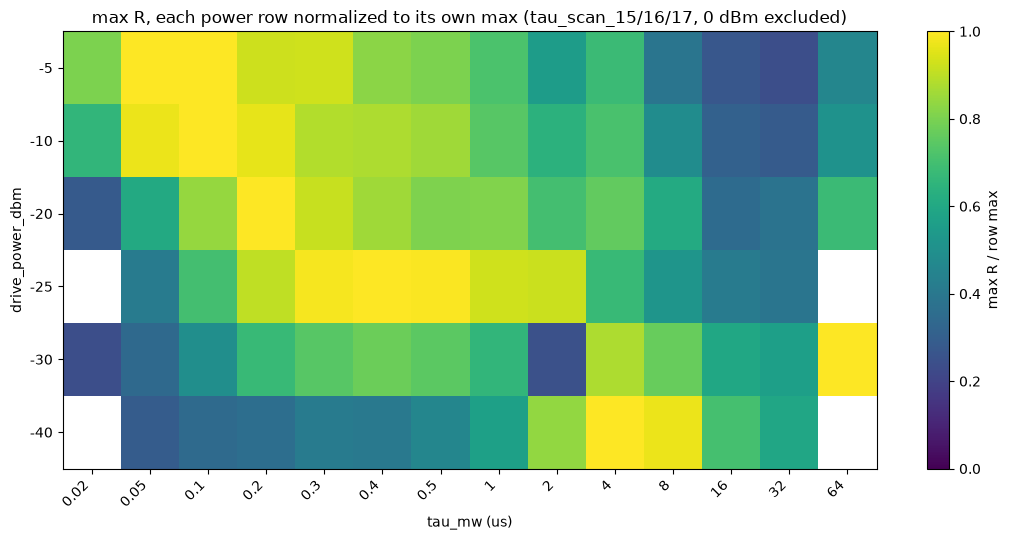

power=-40 dBm: peak at tau_mw=4 us (84.9 uV)
power=-30 dBm: peak at tau_mw=64 us (96.6 uV)
power=-25 dBm: peak at tau_mw=0.4 us (145.4 uV)
power=-20 dBm: peak at tau_mw=0.2 us (148.3 uV)
power=-10 dBm: peak at tau_mw=0.1 us (194.9 uV)
power=-5 dBm: peak at tau_mw=0.05 us (217.9 uV)


In [4]:
row_max = np.nanmax(grid, axis=1, keepdims=True)
grid_norm = grid / row_max

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(grid_norm, aspect="auto", origin="lower", cmap="viridis",
                vmin=0, vmax=1,
                extent=[-0.5, len(tau_values) - 0.5, -0.5, len(power_values) - 0.5])
ax.set_xticks(range(len(tau_values)))
ax.set_xticklabels([f"{t:g}" for t in tau_values], rotation=45, ha="right")
ax.set_yticks(range(len(power_values)))
ax.set_yticklabels([f"{p:g}" for p in power_values])
ax.set_xlabel("tau_mw (us)")
ax.set_ylabel("drive_power_dbm")
ax.set_title("max R, each power row normalized to its own max (tau_scan_15/16/17, 0 dBm excluded)")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("max R / row max")
plt.tight_layout()
plt.show()

for i, power_dbm in enumerate(power_values):
    j_peak = np.nanargmax(grid[i])
    print(f"power={power_dbm:g} dBm: peak at tau_mw={tau_values[j_peak]:g} us "
          f"({grid[i, j_peak]:.1f} uV)")